# PART A — Global configuration

First, replace the scattered configuration in the original notebook with one controlled configuration block.

In [40]:
# ============================================================
# HDBSCAN PARAMETER GRID SEARCH
# Reviewer-Corrected Multi-Omics Pipeline
#
# Modality: miRNA
#
# Pipeline:
# CSV
#   ↓
# Feature extraction
#   ↓
# StandardScaler
#   ↓
# PCA (95% variance)
#   ↓
# HDBSCAN grid search
#   ↓
# Clustering-quality evaluation
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import hdbscan

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

warnings.filterwarnings("ignore")


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)


# ============================================================
# 2. DATASET
# ============================================================

DATA_PATH = "/content/meth.csv"

MODALITY = "methylation"


# ============================================================
# 3. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = (
    f"/content/{MODALITY}_Reviewer_Corrected_Results"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 4. HDBSCAN SEARCH SPACE
# ============================================================

MIN_CLUSTER_SIZES = [
    5,
    10,
    20,
    30,
    40,
    50,
    60,
    70,
    80,
    90,
    100
]

MIN_SAMPLES = [
    1,
    2,
    5,
    10,
    15,
    20,
    25,
    30,
    35,
    40,
    45
]

HDBSCAN_METRIC = "euclidean"

HDBSCAN_CLUSTER_SELECTION = "eom"


# ============================================================
# 5. PCA CONFIGURATION
# ============================================================

PCA_VARIANCE = 0.95


# ============================================================
# 6. LOAD DATASET
# ============================================================

print("=" * 80)
print("LOADING DATASET")
print("=" * 80)

print(
    "Dataset:",
    DATA_PATH
)

df = pd.read_csv(
    DATA_PATH
)

print(
    "Original shape:",
    df.shape
)

print(
    "\nColumns:"
)

print(
    df.columns.tolist()
)


# ============================================================
# 7. IDENTIFY NUMERIC FEATURES
# ============================================================

numeric_columns = df.select_dtypes(
    include=[np.number]
).columns.tolist()


print()
print("=" * 80)
print("NUMERIC FEATURES")
print("=" * 80)

print(
    "Number of numeric columns:",
    len(numeric_columns)
)


# ============================================================
# 8. REMOVE POSSIBLE LABEL / TARGET COLUMNS
# ============================================================
#
# HDBSCAN is unsupervised.
#
# Therefore, outcome / class / label columns must NOT be
# included in the clustering feature matrix.
#
# The code removes common label names if present.
# ============================================================

POSSIBLE_LABEL_COLUMNS = [
    "label",
    "Label",
    "LABEL",
    "class",
    "Class",
    "CLASS",
    "target",
    "Target",
    "TARGET",
    "y",
    "Y",
    "group",
    "Group",
    "GROUP"
]


label_columns_found = [
    col
    for col in POSSIBLE_LABEL_COLUMNS
    if col in numeric_columns
]


if label_columns_found:

    print()
    print(
        "Possible label columns detected:"
    )

    print(
        label_columns_found
    )

    feature_columns = [
        col
        for col in numeric_columns
        if col not in label_columns_found
    ]

else:

    feature_columns = numeric_columns.copy()


# ============================================================
# 9. CREATE FEATURE MATRIX
# ============================================================

X = df[
    feature_columns
].copy()


print()
print("=" * 80)
print("FEATURE MATRIX")
print("=" * 80)

print(
    "Feature matrix shape:",
    X.shape
)

print(
    "Features used:",
    len(feature_columns)
)


# ============================================================
# 10. HANDLE MISSING / INFINITE VALUES
# ============================================================

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


missing_before = X.isna().sum().sum()


print()
print(
    "Missing values before imputation:",
    missing_before
)


if missing_before > 0:

    X = X.fillna(
        X.median()
    )


missing_after = X.isna().sum().sum()


print(
    "Missing values after imputation:",
    missing_after
)


# ============================================================
# 11. CONVERT TO NUMPY
# ============================================================

X = X.to_numpy(
    dtype=np.float64
)


print()
print(
    "Final numeric matrix:",
    X.shape
)


# ============================================================
# 12. STANDARDIZATION
# ============================================================

print()
print("=" * 80)
print("STANDARDIZATION")
print("=" * 80)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

print(
    "Standardized shape:",
    X_scaled.shape
)


# ============================================================
# 13. PCA
# ============================================================
#
# Retain 95% explained variance.
#
# PCA is performed BEFORE HDBSCAN to reduce dimensionality
# and noise in high-dimensional miRNA data.
# ============================================================

print()
print("=" * 80)
print("PCA")
print("=" * 80)

pca = PCA(
    n_components=PCA_VARIANCE,
    random_state=SEED
)

X_pca = pca.fit_transform(
    X_scaled
)


explained_variance = (
    np.sum(
        pca.explained_variance_ratio_
    ) * 100
)


print(
    "Original dimensions:",
    X_scaled.shape[1]
)

print(
    "PCA dimensions:",
    X_pca.shape[1]
)

print(
    "Explained variance:",
    round(
        explained_variance,
        2
    ),
    "%"
)


# ============================================================
# 14. SAVE PCA INFORMATION
# ============================================================

pca_info = pd.DataFrame({

    "Original_Dimensions": [
        X_scaled.shape[1]
    ],

    "PCA_Dimensions": [
        X_pca.shape[1]
    ],

    "Explained_Variance_Percent": [
        explained_variance
    ]
})


pca_info_path = os.path.join(
    OUTPUT_DIR,
    f"{MODALITY}_PCA_Information.csv"
)

pca_info.to_csv(
    pca_info_path,
    index=False
)


# ============================================================
# 15. HDBSCAN INPUT
# ============================================================

X_hdbscan = np.asarray(
    X_pca,
    dtype=np.float64
)


print()
print("=" * 80)
print("HDBSCAN INPUT")
print("=" * 80)

print(
    "HDBSCAN input shape:",
    X_hdbscan.shape
)


# ============================================================
# 16. GRID SEARCH
# ============================================================

print()
print("=" * 80)
print("HDBSCAN PARAMETER GRID SEARCH")
print("=" * 80)


hdbscan_results = []


for min_cluster_size in MIN_CLUSTER_SIZES:

    for min_samples in MIN_SAMPLES:

        print(
            f"Testing "
            f"min_cluster_size={min_cluster_size}, "
            f"min_samples={min_samples}"
        )


        # ----------------------------------------------------
        # HDBSCAN
        # ----------------------------------------------------

        clusterer = hdbscan.HDBSCAN(

            min_cluster_size=min_cluster_size,

            min_samples=min_samples,

            metric=HDBSCAN_METRIC,

            cluster_selection_method=(
                HDBSCAN_CLUSTER_SELECTION
            ),

            prediction_data=True
        )


        labels = clusterer.fit_predict(
            X_hdbscan
        )


        # ----------------------------------------------------
        # Noise
        # ----------------------------------------------------

        noise_mask = (
            labels == -1
        )

        n_noise = int(
            np.sum(noise_mask)
        )

        n_total = len(
            labels
        )

        noise_percentage = (
            100.0 *
            n_noise /
            n_total
        )


        # ----------------------------------------------------
        # Non-noise data
        # ----------------------------------------------------

        valid_mask = (
            ~noise_mask
        )

        X_valid = X_hdbscan[
            valid_mask
        ]

        labels_valid = labels[
            valid_mask
        ]


        # ----------------------------------------------------
        # Number of clusters
        # ----------------------------------------------------

        unique_clusters = np.unique(
            labels_valid
        )

        n_clusters = len(
            unique_clusters
        )


        # ----------------------------------------------------
        # Clustering metrics
        # ----------------------------------------------------

        if (
            n_clusters >= 2
            and
            len(X_valid) > n_clusters
        ):

            try:

                silhouette = silhouette_score(
                    X_valid,
                    labels_valid
                )

            except Exception:

                silhouette = np.nan


            try:

                davies_bouldin = (
                    davies_bouldin_score(
                        X_valid,
                        labels_valid
                    )
                )

            except Exception:

                davies_bouldin = np.nan


            try:

                calinski_harabasz = (
                    calinski_harabasz_score(
                        X_valid,
                        labels_valid
                    )
                )

            except Exception:

                calinski_harabasz = np.nan

        else:

            silhouette = np.nan

            davies_bouldin = np.nan

            calinski_harabasz = np.nan


        # ----------------------------------------------------
        # Cluster persistence
        # ----------------------------------------------------

        persistence = (
            clusterer.cluster_persistence_
        )


        if len(persistence) > 0:

            mean_persistence = (
                np.mean(persistence)
            )

            min_persistence = (
                np.min(persistence)
            )

        else:

            mean_persistence = np.nan

            min_persistence = np.nan


        # ----------------------------------------------------
        # Membership probability
        # ----------------------------------------------------

        probabilities = (
            clusterer.probabilities_
        )


        clustered_probabilities = (
            probabilities[
                valid_mask
            ]
        )


        if len(
            clustered_probabilities
        ) > 0:

            mean_probability = (
                np.mean(
                    clustered_probabilities
                )
            )

            median_probability = (
                np.median(
                    clustered_probabilities
                )
            )

        else:

            mean_probability = np.nan

            median_probability = np.nan


        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        hdbscan_results.append({

            "min_cluster_size":
                min_cluster_size,

            "min_samples":
                min_samples,

            "n_clusters":
                n_clusters,

            "n_noise":
                n_noise,

            "noise_percentage":
                noise_percentage,

            "silhouette_score":
                silhouette,

            "davies_bouldin_score":
                davies_bouldin,

            "calinski_harabasz_score":
                calinski_harabasz,

            "mean_cluster_persistence":
                mean_persistence,

            "min_cluster_persistence":
                min_persistence,

            "mean_membership_probability":
                mean_probability,

            "median_membership_probability":
                median_probability
        })


# ============================================================
# 17. RESULTS DATAFRAME
# ============================================================

hdbscan_grid = pd.DataFrame(
    hdbscan_results
)


# ============================================================
# 18. DISPLAY FULL RESULTS
# ============================================================

print()
print("=" * 80)
print("HDBSCAN GRID SEARCH RESULTS")
print("=" * 80)

print(
    hdbscan_grid.to_string(
        index=False
    )
)


# ============================================================
# 19. SAVE RAW GRID RESULTS
# ============================================================

grid_path = os.path.join(
    OUTPUT_DIR,
    f"{MODALITY}_HDBSCAN_Parameter_Grid_Search.csv"
)

hdbscan_grid.to_csv(
    grid_path,
    index=False
)


print()
print(
    "Grid results saved:"
)

print(
    grid_path
)


# ============================================================
# 20. REMOVE INVALID METRIC RESULTS
# ============================================================

valid_results = (
    hdbscan_grid.dropna(
        subset=[
            "silhouette_score",
            "davies_bouldin_score",
            "calinski_harabasz_score"
        ]
    ).copy()
)


print()
print(
    "Valid configurations:",
    len(valid_results),
    "/",
    len(hdbscan_grid)
)


# ============================================================
# 21. MULTI-CRITERIA NORMALIZATION
# ============================================================

if len(valid_results) > 0:

    # --------------------------------------------------------
    # Silhouette
    # HIGHER = BETTER
    # --------------------------------------------------------

    sil_min = (
        valid_results[
            "silhouette_score"
        ].min()
    )

    sil_max = (
        valid_results[
            "silhouette_score"
        ].max()
    )


    if sil_max > sil_min:

        valid_results[
            "silhouette_norm"
        ] = (

            valid_results[
                "silhouette_score"
            ] - sil_min

        ) / (

            sil_max - sil_min
        )

    else:

        valid_results[
            "silhouette_norm"
        ] = 1.0


    # --------------------------------------------------------
    # Calinski-Harabasz
    # HIGHER = BETTER
    # --------------------------------------------------------

    ch_min = (
        valid_results[
            "calinski_harabasz_score"
        ].min()
    )

    ch_max = (
        valid_results[
            "calinski_harabasz_score"
        ].max()
    )


    if ch_max > ch_min:

        valid_results[
            "calinski_norm"
        ] = (

            valid_results[
                "calinski_harabasz_score"
            ] - ch_min

        ) / (

            ch_max - ch_min
        )

    else:

        valid_results[
            "calinski_norm"
        ] = 1.0


    # --------------------------------------------------------
    # Davies-Bouldin
    # LOWER = BETTER
    # --------------------------------------------------------

    db_min = (
        valid_results[
            "davies_bouldin_score"
        ].min()
    )

    db_max = (
        valid_results[
            "davies_bouldin_score"
        ].max()
    )


    if db_max > db_min:

        valid_results[
            "davies_bouldin_norm"
        ] = (

            db_max -

            valid_results[
                "davies_bouldin_score"
            ]

        ) / (

            db_max - db_min
        )

    else:

        valid_results[
            "davies_bouldin_norm"
        ] = 1.0


# ============================================================
# 22. COMPOSITE CLUSTERING QUALITY SCORE
# ============================================================
#
# 40% Silhouette
# 30% Calinski-Harabasz
# 30% Davies-Bouldin
#
# Reconstruction residuals are NOT used.
# GLOSH is NOT used for parameter selection.
# ============================================================

if len(valid_results) > 0:

    valid_results[
        "clustering_quality_score"
    ] = (

        0.40 *
        valid_results[
            "silhouette_norm"
        ]

        +

        0.30 *
        valid_results[
            "calinski_norm"
        ]

        +

        0.30 *
        valid_results[
            "davies_bouldin_norm"
        ]
    )


# ============================================================
# 23. NOISE DIAGNOSTIC
# ============================================================
#
# 5-30% is treated ONLY as a practical diagnostic range.
#
# It is NOT a universal biological rule.
# ============================================================

if len(valid_results) > 0:

    valid_results[
        "reasonable_noise"
    ] = (

        valid_results[
            "noise_percentage"
        ].between(
            5,
            30
        )
    )


# ============================================================
# 24. SELECT PARAMETERS
# ============================================================

if len(valid_results) == 0:

    raise RuntimeError(
        "No valid HDBSCAN configuration "
        "produced at least two clusters."
    )


reasonable_results = (
    valid_results[
        valid_results[
            "reasonable_noise"
        ]
    ].copy()
)


if len(reasonable_results) > 0:

    ranked_results = (
        reasonable_results
        .sort_values(
            by="clustering_quality_score",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    print()
    print(
        "Ranking configurations with "
        "5-30% noise."
    )

else:

    ranked_results = (
        valid_results
        .sort_values(
            by="clustering_quality_score",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    print()
    print(
        "No configuration produced "
        "5-30% noise."
    )

    print(
        "Ranking all valid configurations."
    )


# ============================================================
# 25. BEST PARAMETERS
# ============================================================

BEST_MIN_CLUSTER_SIZE = int(
    ranked_results.iloc[0][
        "min_cluster_size"
    ]
)

BEST_MIN_SAMPLES = int(
    ranked_results.iloc[0][
        "min_samples"
    ]
)


# ============================================================
# 26. PRINT BEST RESULT
# ============================================================

best = ranked_results.iloc[0]


print()
print("=" * 80)
print("RECOMMENDED HDBSCAN PARAMETERS")
print("=" * 80)

print(
    "Best min_cluster_size :",
    BEST_MIN_CLUSTER_SIZE
)

print(
    "Best min_samples      :",
    BEST_MIN_SAMPLES
)

print(
    "Number of clusters    :",
    int(best["n_clusters"])
)

print(
    "Noise samples         :",
    int(best["n_noise"])
)

print(
    "Noise percentage      :",
    round(
        best["noise_percentage"],
        2
    ),
    "%"
)

print(
    "Silhouette Score      :",
    round(
        best["silhouette_score"],
        4
    )
)

print(
    "Davies-Bouldin Score  :",
    round(
        best["davies_bouldin_score"],
        4
    )
)

print(
    "Calinski-Harabasz     :",
    round(
        best["calinski_harabasz_score"],
        4
    )
)

print(
    "Mean Persistence      :",
    round(
        best["mean_cluster_persistence"],
        4
    )
)

print(
    "Mean Membership Prob. :",
    round(
        best["mean_membership_probability"],
        4
    )
)

print(
    "Composite Score       :",
    round(
        best["clustering_quality_score"],
        4
    )
)


# ============================================================
# 27. SAVE RANKED RESULTS
# ============================================================

ranked_path = os.path.join(
    OUTPUT_DIR,
    f"{MODALITY}_HDBSCAN_Ranked_Parameters.csv"
)

ranked_results.to_csv(
    ranked_path,
    index=False
)


print()
print(
    "Ranked results saved:"
)

print(
    ranked_path
)


# ============================================================
# 28. UPDATE GLOBAL CONFIGURATION
# ============================================================

HDBSCAN_MIN_CLUSTER_SIZE = (
    BEST_MIN_CLUSTER_SIZE
)

HDBSCAN_MIN_SAMPLES = (
    BEST_MIN_SAMPLES
)


# ============================================================
# 29. FINAL CONFIGURATION
# ============================================================

print()
print("=" * 80)
print("FINAL HDBSCAN CONFIGURATION")
print("=" * 80)

print(
    "HDBSCAN_MIN_CLUSTER_SIZE =",
    HDBSCAN_MIN_CLUSTER_SIZE
)

print(
    "HDBSCAN_MIN_SAMPLES      =",
    HDBSCAN_MIN_SAMPLES
)

print(
    "HDBSCAN_METRIC           =",
    HDBSCAN_METRIC
)

print(
    "HDBSCAN_CLUSTER_SELECTION =",
    HDBSCAN_CLUSTER_SELECTION
)

print("=" * 80)
print("HDBSCAN GRID SEARCH COMPLETED")
print("=" * 80)

LOADING DATASET
Dataset: /content/meth.csv
Original shape: (875, 1000)

Columns:
['A2LD1', 'A2ML1', 'ABAT', 'ABCA13', 'ABCC11', 'ABHD3', 'ABT1', 'ACSM2A', 'ACSM5', 'ACYP1', 'ADAM8', 'ADAMTS3', 'ADAMTSL5', 'ADAP1', 'ADCY3', 'ADCY4', 'ADCYAP1R1', 'ADORA3', 'AGR2', 'AGR3', 'AHCYL2', 'AHSG', 'AHSP', 'AKNAD1', 'AKR1E2', 'ALDH1A3', 'ALDH3A1', 'ALDH5A1', 'ALPL', 'AMHR2', 'ANGEL2', 'ANGPTL2', 'ANKRD53', 'ANKS1B', 'ANXA8L2', 'ANXA9', 'APBA2', 'APOBEC4', 'AQP7P1', 'AQP7P2', 'ARAP3', 'ARHGAP10', 'ARHGAP21', 'ARHGAP28', 'ARHGEF1', 'ARHGEF10L', 'ARHGEF2', 'ARID2', 'ARL4C', 'ARNTL2', 'ARRDC2', 'ASAP2', 'ASB16', 'ASF1A', 'ASPRV1', 'ATOH8', 'ATP10B', 'ATP6AP1L', 'ATP8B1', 'AUH', 'AVEN', 'B3GNT5', 'B3GNTL1', 'B4GALT6', 'BAG3', 'BAIAP3', 'BARD1', 'BARHL2', 'BASE', 'BCAN', 'BCAS1', 'BCAS4', 'BCL10', 'BCL2L1', 'BGLAP', 'BHLHE40', 'BIN2', 'BIN3', 'BIRC5', 'BLID', 'BLOC1S1', 'BNC1', 'BPI', 'BPIL1', 'BRF2', 'BRI3', 'BTG3', 'C10orf108', 'C10orf125', 'C10orf81', 'C10orf90', 'C10orf91', 'C11orf34', 'C11orf86', 

In [41]:
# ============================================================
# GLOBAL CONFIGURATION
# Reviewer-Corrected Multi-Omics Pipeline
# ============================================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

DATA_PATH = "/content/meth.csv"

# Change this for methylation / miRNA:
MODALITY = "methylation"

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

OUTPUT_DIR = f"/content/{MODALITY}_Reviewer_Corrected_Results"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# Data split
# ------------------------------------------------------------

TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

assert abs(
    TRAIN_SIZE + VAL_SIZE + TEST_SIZE - 1.0
) < 1e-8

# ------------------------------------------------------------
# Autoencoder
# ------------------------------------------------------------

LATENT_DIM = 64

EPOCHS = 500

BATCH_SIZE = 64

DROPOUT_RATE = 0.30

L2_REG = 1e-6

L1_LATENT = 1e-5

INITIAL_LR = 1e-4

FINAL_LR = 1e-5

# ------------------------------------------------------------
# HDBSCAN
# ------------------------------------------------------------

HDBSCAN_MIN_CLUSTER_SIZE = 10

HDBSCAN_MIN_SAMPLES = 10

HDBSCAN_METRIC = "euclidean"

HDBSCAN_CLUSTER_SELECTION = "eom"

# ------------------------------------------------------------
# DE
# ------------------------------------------------------------

FDR_THRESHOLD = 0.05

LOG2FC_THRESHOLD = 1.0

TOP_N_GENES = 50

# ------------------------------------------------------------
# PCA matched ranks
# ------------------------------------------------------------

MATCHED_PCA_COMPONENTS = {
    "methylation": 14,
    "mRNA": 15,
    "miRNA": 29
}

print("=" * 80)
print("REVIEWER-CORRECTED MULTI-OMICS PIPELINE")
print("=" * 80)

print("Modality :", MODALITY)
print("Seed     :", SEED)
print("Output   :", OUTPUT_DIR)

REVIEWER-CORRECTED MULTI-OMICS PIPELINE
Modality : methylation
Seed     : 42
Output   : /content/methylation_Reviewer_Corrected_Results


# PART B — STEP 1: Load and validate data

In [45]:
df = pd.read_csv("/content/meth.csv")

In [46]:
# ============================================================
# STEP 1 : Load Dataset
# ============================================================

df = pd.read_csv(DATA_PATH)

print("=" * 80)
print(f"{MODALITY} DATASET")
print("=" * 80)

print("Shape :", df.shape)

# ------------------------------------------------------------
# Remove completely empty rows / columns
# ------------------------------------------------------------

df = df.dropna(
    axis=0,
    how="all"
)

df = df.dropna(
    axis=1,
    how="all"
)

# ------------------------------------------------------------
# Check numeric features
# ------------------------------------------------------------

non_numeric_columns = df.select_dtypes(
    exclude=[np.number]
).columns.tolist()

if len(non_numeric_columns) > 0:

    print(
        "Non-numeric columns detected:",
        non_numeric_columns
    )

    raise ValueError(
        "Expression matrix must contain numeric molecular features only."
    )

# ------------------------------------------------------------
# Missing-value check
# ------------------------------------------------------------

missing_values = df.isna().sum().sum()

print("Missing values :", missing_values)

if missing_values > 0:

    raise ValueError(
        "Missing values detected. Handle them before this pipeline."
    )

# ------------------------------------------------------------
# Infinite values
# ------------------------------------------------------------

if not np.isfinite(df.values).all():

    raise ValueError(
        "Infinite values detected."
    )

print("Final Shape :", df.shape)

methylation DATASET
Shape : (875, 1000)
Missing values : 0
Final Shape : (875, 1000)


# PART C — STEP 2: Preserve the original expression matrix

This is important for fixing the log2FC problem.

In [47]:
# ============================================================
# STEP 2 : Preserve Raw Biological Expression Matrix
# ============================================================

expression_raw = df.copy()

feature_names = expression_raw.columns.tolist()

print("Samples :", expression_raw.shape[0])
print("Features:", expression_raw.shape[1])

print(
    "Raw expression matrix preserved for downstream "
    "effect-size and biological analyses."
)

Samples : 875
Features: 1000
Raw expression matrix preserved for downstream effect-size and biological analyses.


# PART D — STEP 3: 70/15/15 split

This addresses M1 and creates the foundation for M3.

In [48]:
# ============================================================
# STEP 3 : 70/15/15 Sample Split
# ============================================================

from sklearn.model_selection import train_test_split

sample_indices = np.arange(
    len(expression_raw)
)

# ------------------------------------------------------------
# First split:
# 70% train
# 30% temporary
# ------------------------------------------------------------

train_idx, temp_idx = train_test_split(
    sample_indices,
    test_size=(VAL_SIZE + TEST_SIZE),
    random_state=SEED,
    shuffle=True
)

# ------------------------------------------------------------
# Second split:
# 15% validation
# 15% test
# ------------------------------------------------------------

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    random_state=SEED,
    shuffle=True
)

print("=" * 80)
print("SAMPLE SPLIT")
print("=" * 80)

print("Train :", len(train_idx))
print("Val   :", len(val_idx))
print("Test  :", len(test_idx))

print(
    "Total :",
    len(train_idx) +
    len(val_idx) +
    len(test_idx)
)

assert (
    len(
        set(train_idx) &
        set(val_idx)
    ) == 0
)

assert (
    len(
        set(train_idx) &
        set(test_idx)
    ) == 0
)

assert (
    len(
        set(val_idx) &
        set(test_idx)
    ) == 0
)

SAMPLE SPLIT
Train : 612
Val   : 131
Test  : 132
Total : 875


# PART E — STEP 4: Train-only scaling

In [49]:
# ============================================================
# STEP 4 : Train-Only Standardization
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_raw = expression_raw.iloc[
    train_idx
].values

X_val_raw = expression_raw.iloc[
    val_idx
].values

X_test_raw = expression_raw.iloc[
    test_idx
].values

# ------------------------------------------------------------
# FIT ONLY ON TRAIN
# ------------------------------------------------------------

X_train_scaled = scaler.fit_transform(
    X_train_raw
)

# ------------------------------------------------------------
# TRANSFORM ONLY
# ------------------------------------------------------------

X_val_scaled = scaler.transform(
    X_val_raw
)

X_test_scaled = scaler.transform(
    X_test_raw
)

print("=" * 80)
print("TRAIN-ONLY STANDARDIZATION")
print("=" * 80)

print("Train:", X_train_scaled.shape)
print("Val  :", X_val_scaled.shape)
print("Test :", X_test_scaled.shape)

TRAIN-ONLY STANDARDIZATION
Train: (612, 1000)
Val  : (131, 1000)
Test : (132, 1000)


# PART F — STEP 5: DAE architecture

In [50]:
# ============================================================
# STEP 5 : Denoising Autoencoder
# ============================================================

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.optimizers import Adam


def create_autoencoder(
    input_dim,
    latent_dim=64,
    dropout_rate=0.30,
    l2_reg=1e-6,
    l1_latent=1e-5
):

    input_layer = Input(
        shape=(input_dim,),
        name="input"
    )

    # --------------------------------------------------------
    # Encoder
    # --------------------------------------------------------

    x = Dense(
        512,
        activation="relu",
        kernel_regularizer=l2(l2_reg)
    )(input_layer)

    x = BatchNormalization()(x)

    x = Dropout(
        dropout_rate
    )(x)

    x = Dense(
        256,
        activation="relu",
        kernel_regularizer=l2(l2_reg)
    )(x)

    x = BatchNormalization()(x)

    x = Dropout(
        dropout_rate
    )(x)

    x = Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(l2_reg)
    )(x)

    latent = Dense(
        latent_dim,
        activation="relu",
        activity_regularizer=l1(l1_latent),
        name="latent"
    )(x)

    # --------------------------------------------------------
    # Decoder
    # --------------------------------------------------------

    x = Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(l2_reg)
    )(latent)

    x = BatchNormalization()(x)

    x = Dropout(
        dropout_rate
    )(x)

    x = Dense(
        256,
        activation="relu",
        kernel_regularizer=l2(l2_reg)
    )(x)

    x = BatchNormalization()(x)

    x = Dropout(
        dropout_rate
    )(x)

    x = Dense(
        512,
        activation="relu",
        kernel_regularizer=l2(l2_reg)
    )(x)

    output = Dense(
        input_dim,
        activation="linear",
        name="reconstruction"
    )(x)

    autoencoder = Model(
        input_layer,
        output,
        name=f"{MODALITY}_DAE"
    )

    encoder = Model(
        input_layer,
        latent,
        name=f"{MODALITY}_Encoder"
    )

    return autoencoder, encoder

# PART G — STEP 6: Cosine learning-rate scheduler

In [51]:
# ============================================================
# STEP 6 : Cosine Annealing Learning Rate
# ============================================================

import math

def cosine_lr(
    epoch,
    initial_lr=1e-4,
    final_lr=1e-5,
    total_epochs=500
):

    cosine = (
        1 +
        math.cos(
            math.pi *
            epoch /
            total_epochs
        )
    ) / 2

    return (
        final_lr +
        (initial_lr - final_lr) *
        cosine
    )

# PART H — STEP 7: Train DAE-MSE

In [52]:
# ============================================================
# STEP 7 : Train DAE-MSE
# ============================================================

from tensorflow.keras.callbacks import LearningRateScheduler

dae_mse, encoder_mse = create_autoencoder(
    input_dim=X_train_scaled.shape[1],
    latent_dim=LATENT_DIM,
    dropout_rate=DROPOUT_RATE,
    l2_reg=L2_REG,
    l1_latent=L1_LATENT
)

dae_mse.compile(
    optimizer=Adam(
        learning_rate=INITIAL_LR
    ),
    loss="mse"
)

lr_callback_mse = LearningRateScheduler(
    lambda epoch: cosine_lr(
        epoch,
        INITIAL_LR,
        FINAL_LR,
        EPOCHS
    ),
    verbose=0
)

history_mse = dae_mse.fit(
    X_train_scaled,
    X_train_scaled,

    validation_data=(
        X_val_scaled,
        X_val_scaled
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    shuffle=True,

    callbacks=[
        lr_callback_mse
    ],

    verbose=1
)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 695ms/step - loss: 1.2952 - val_loss: 1.0232 - learning_rate: 1.0000e-04
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2273 - val_loss: 1.0184 - learning_rate: 9.9999e-05
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1777 - val_loss: 1.0115 - learning_rate: 9.9996e-05
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1280 - val_loss: 0.9977 - learning_rate: 9.9992e-05
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0683 - val_loss: 0.9705 - learning_rate: 9.9986e-05
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0015 - val_loss: 0.9216 - learning_rate: 9.9978e-05
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9183 - val_loss: 0.8469 - learning_rate: 9.9968e-05
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.8469 - val_loss: 0.7578 - learning_rate: 9.9956e-05
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7900 - val_loss: 0.6838 

# PART I — STEP 8: Train DAE-Huber

In [53]:
# ============================================================
# STEP 8 : Train DAE-Huber
# ============================================================

from tensorflow.keras.losses import Huber

dae_huber, encoder_huber = create_autoencoder(
    input_dim=X_train_scaled.shape[1],
    latent_dim=LATENT_DIM,
    dropout_rate=DROPOUT_RATE,
    l2_reg=L2_REG,
    l1_latent=L1_LATENT
)

dae_huber.compile(
    optimizer=Adam(
        learning_rate=INITIAL_LR
    ),
    loss=Huber()
)

lr_callback_huber = LearningRateScheduler(
    lambda epoch: cosine_lr(
        epoch,
        INITIAL_LR,
        FINAL_LR,
        EPOCHS
    ),
    verbose=0
)

history_huber = dae_huber.fit(
    X_train_scaled,
    X_train_scaled,

    validation_data=(
        X_val_scaled,
        X_val_scaled
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    shuffle=True,

    callbacks=[
        lr_callback_huber
    ],

    verbose=1
)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 709ms/step - loss: 0.5154 - val_loss: 0.4250 - learning_rate: 1.0000e-04
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4910 - val_loss: 0.4232 - learning_rate: 9.9999e-05
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4749 - val_loss: 0.4204 - learning_rate: 9.9996e-05
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4576 - val_loss: 0.4143 - learning_rate: 9.9992e-05
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4365 - val_loss: 0.4027 - learning_rate: 9.9986e-05
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4112 - val_loss: 0.3815 - learning_rate: 9.9978e-05
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3801 - val_loss: 0.3518 - learning_rate: 9.9968e-05
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3508 - val_loss: 0.3185 - learning_rate: 9.9956e-05
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3317 - val_loss: 0.2937 

# PART J — STEP 9: MSLE needs special treatment

This is important.


Report both losses for both models on held-out data.

But data are standardized:

negative values

and MSLE is designed for non-negative quantities.

So do not blindly apply MSLE to standardized values.

For the corrected experiment, if you want MSLE as a model objective, create a separate nonnegative representation using MinMax scaling.

In [54]:
# ============================================================
# STEP 9 : Non-negative Representation for MSLE
# ============================================================

from sklearn.preprocessing import MinMaxScaler

msle_scaler = MinMaxScaler()

X_train_msle = msle_scaler.fit_transform(
    X_train_raw
)

X_val_msle = msle_scaler.transform(
    X_val_raw
)

X_test_msle = msle_scaler.transform(
    X_test_raw
)

print("MSLE train shape:", X_train_msle.shape)

MSLE train shape: (612, 1000)


In [55]:
# ============================================================
# STEP 9.1 : Train DAE-MSLE
# ============================================================

from tensorflow.keras.losses import MeanSquaredLogarithmicError

dae_msle, encoder_msle = create_autoencoder(
    input_dim=X_train_msle.shape[1],
    latent_dim=LATENT_DIM,
    dropout_rate=DROPOUT_RATE,
    l2_reg=L2_REG,
    l1_latent=L1_LATENT
)

dae_msle.compile(
    optimizer=Adam(
        learning_rate=INITIAL_LR
    ),
    loss=MeanSquaredLogarithmicError()
)

lr_callback_msle = LearningRateScheduler(
    lambda epoch: cosine_lr(
        epoch,
        INITIAL_LR,
        FINAL_LR,
        EPOCHS
    ),
    verbose=0
)

history_msle = dae_msle.fit(
    X_train_msle,
    X_train_msle,

    validation_data=(
        X_val_msle,
        X_val_msle
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    shuffle=True,

    callbacks=[
        lr_callback_msle
    ],

    verbose=1
)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 572ms/step - loss: 0.1585 - val_loss: 0.2023 - learning_rate: 1.0000e-04
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1392 - val_loss: 0.1981 - learning_rate: 9.9999e-05
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1216 - val_loss: 0.1842 - learning_rate: 9.9996e-05
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1076 - val_loss: 0.1624 - learning_rate: 9.9992e-05
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0966 - val_loss: 0.1404 - learning_rate: 9.9986e-05
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0896 - val_loss: 0.1216 - learning_rate: 9.9978e-05
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0843 - val_loss: 0.1068 - learning_rate: 9.9968e-05
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0808 - val_loss: 0.0942 - learning_rate: 9.9956e-05
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0767 - val_loss: 0.0814 

# PART K — STEP 10: Evaluate all models on TEST

In [56]:
# ============================================================
# STEP 10 : Held-Out Reconstruction Evaluation
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def evaluate_reconstruction(
    original,
    reconstructed
):

    mae = mean_absolute_error(
        original,
        reconstructed
    )

    mse = mean_squared_error(
        original,
        reconstructed
    )

    rmse = np.sqrt(mse)

    max_ae = np.max(
        np.abs(
            original -
            reconstructed
        )
    )

    r2 = r2_score(
        original,
        reconstructed
    )

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "Max_AE": max_ae,
        "R2": r2
    }


# ------------------------------------------------------------
# TEST reconstructions
# ------------------------------------------------------------

X_test_pred_mse = dae_mse.predict(
    X_test_scaled,
    verbose=0
)

X_test_pred_huber = dae_huber.predict(
    X_test_scaled,
    verbose=0
)

X_test_pred_msle = dae_msle.predict(
    X_test_msle,
    verbose=0
)

# ------------------------------------------------------------
# Evaluate MSE / Huber on standardized test data
# ------------------------------------------------------------

metrics_mse = evaluate_reconstruction(
    X_test_scaled,
    X_test_pred_mse
)

metrics_huber = evaluate_reconstruction(
    X_test_scaled,
    X_test_pred_huber
)

# ------------------------------------------------------------
# Evaluate MSLE on its own non-negative test representation
# ------------------------------------------------------------

metrics_msle = evaluate_reconstruction(
    X_test_msle,
    X_test_pred_msle
)

test_reconstruction_results = pd.DataFrame(
    [
        {
            "Model": "DAE-MSE",
            **metrics_mse
        },
        {
            "Model": "DAE-Huber",
            **metrics_huber
        },
        {
            "Model": "DAE-MSLE",
            **metrics_msle
        }
    ]
)

print(
    test_reconstruction_results
)

test_reconstruction_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "Heldout_Reconstruction_Test.csv"
    ),
    index=False
)

       Model       MAE       MSE      RMSE    Max_AE        R2
0    DAE-MSE  0.409544  0.345930  0.588159  5.995029  0.669102
1  DAE-Huber  0.410623  0.358056  0.598377  7.990449  0.658257
2   DAE-MSLE  0.104221  0.019163  0.138430  0.863065  0.254256


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import hdbscan

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

from statsmodels.stats.multitest import multipletests

# PART L — STEP 11: PCA matched-rank baseline

In [58]:
# ============================================================
# STEP 11 : Matched-Rank PCA Reconstruction Baseline
# ============================================================

matched_rank = MATCHED_PCA_COMPONENTS[
    MODALITY
]

print(
    "Matched PCA rank:",
    matched_rank
)

Matched PCA rank: 14


Fit PCA on train only:

In [59]:
# ============================================================
# STEP 11.1 : Fit PCA on Training Data Only
# ============================================================

pca_matched = PCA(
    n_components=matched_rank,
    random_state=SEED
)

X_train_pca = pca_matched.fit_transform(
    X_train_scaled
)

X_val_pca = pca_matched.transform(
    X_val_scaled
)

X_test_pca = pca_matched.transform(
    X_test_scaled
)

print(
    "Explained variance:",
    round(
        pca_matched.explained_variance_ratio_.sum() * 100,
        4
    ),
    "%"
)

Explained variance: 73.4903 %


Reconstruct:

In [60]:
# ============================================================
# STEP 11.2 : PCA Reconstruction
# ============================================================

X_test_pca_reconstructed = (
    pca_matched.inverse_transform(
        X_test_pca
    )
)

metrics_pca = evaluate_reconstruction(
    X_test_scaled,
    X_test_pca_reconstructed
)

pca_result = {
    "Model": f"PCA-{matched_rank}",
    **metrics_pca,
    "Explained_Variance_Percent":
        pca_matched.explained_variance_ratio_.sum() * 100
}

print(pca_result)

{'Model': 'PCA-14', 'MAE': 0.38148097492945965, 'MSE': 0.30153012600685275, 'RMSE': np.float64(0.5491175885061894), 'Max_AE': np.float64(6.55993839129936), 'R2': 0.7104227990378446, 'Explained_Variance_Percent': np.float64(73.49031239060452)}


Combine:

In [61]:
# ============================================================
# STEP 11.3 : Final M1 Reconstruction Table
# ============================================================

test_reconstruction_results["Explained_Variance_Percent"] = np.nan

pca_results_df = pd.DataFrame(
    [pca_result]
)

final_reconstruction_table = pd.concat(
    [
        test_reconstruction_results,
        pca_results_df
    ],
    ignore_index=True
)

print(
    final_reconstruction_table
)

final_reconstruction_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "M1_Final_Heldout_Reconstruction_Comparison.csv"
    ),
    index=False
)

       Model       MAE       MSE      RMSE    Max_AE        R2  \
0    DAE-MSE  0.409544  0.345930  0.588159  5.995029  0.669102   
1  DAE-Huber  0.410623  0.358056  0.598377  7.990449  0.658257   
2   DAE-MSLE  0.104221  0.019163  0.138430  0.863065  0.254256   
3     PCA-14  0.381481  0.301530  0.549118  6.559938  0.710423   

   Explained_Variance_Percent  
0                         NaN  
1                         NaN  
2                         NaN  
3                   73.490312  


# PART M — STEP 12: M2 matched-dimensionality clustering

This is probably the single most important new analysis in the revision.

In [62]:
# ============================================================
# STEP 12 : HDBSCAN Helper
# ============================================================

import hdbscan


def run_hdbscan(
    X,
    condition_name
):

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
        min_samples=HDBSCAN_MIN_SAMPLES,
        metric=HDBSCAN_METRIC,
        cluster_selection_method=HDBSCAN_CLUSTER_SELECTION,
        prediction_data=True
    )

    labels = clusterer.fit_predict(X)

    probabilities = clusterer.probabilities_

    outlier_scores = clusterer.outlier_scores_

    n_noise = np.sum(
        labels == -1
    )

    n_clusters = len(
        set(labels)
        - {-1}
    )

    noise_percent = (
        n_noise /
        len(labels)
    ) * 100

    summary = {
        "Condition": condition_name,
        "N": len(labels),
        "Dimensions": X.shape[1],
        "Clusters_K": n_clusters,
        "Noise_Samples": int(n_noise),
        "Noise_Percent": noise_percent,
        "Mean_Probability":
            np.mean(probabilities),
        "Median_Probability":
            np.median(probabilities),
        "Mean_GLOSH":
            np.mean(outlier_scores),
        "Median_GLOSH":
            np.median(outlier_scores)
    }

    return (
        clusterer,
        labels,
        probabilities,
        outlier_scores,
        summary
    )

# PART N — M2 RAW PCA matched dimension

In [63]:
# ============================================================
# STEP 12.1 : RAW DATA → MATCHED PCA → HDBSCAN
# ============================================================

raw_clusterer, raw_labels, raw_prob, raw_outlier, raw_summary = (
    run_hdbscan(
        X_test_pca,
        f"Raw_PCA_{matched_rank}"
    )
)

print("=" * 80)
print("RAW MATCHED-DIMENSION HDBSCAN")
print("=" * 80)

print(raw_summary)

RAW MATCHED-DIMENSION HDBSCAN
{'Condition': 'Raw_PCA_14', 'N': 132, 'Dimensions': 14, 'Clusters_K': 2, 'Noise_Samples': 74, 'Noise_Percent': np.float64(56.060606060606055), 'Mean_Probability': np.float64(0.41461075470732806), 'Median_Probability': np.float64(0.0), 'Mean_GLOSH': np.float64(0.24313766165306658), 'Median_GLOSH': np.float64(0.20165956475288277)}


# PART O — DAE reconstruction → matched PCA → HDBSCAN

In [64]:
# ============================================================
# STEP 12.2 : DAE RECONSTRUCTION → MATCHED PCA → HDBSCAN
# ============================================================

# Use MSE DAE for the primary proposed representation.
X_test_dae = X_test_pred_mse

pca_dae_matched = PCA(
    n_components=matched_rank,
    random_state=SEED
)

X_test_dae_pca = pca_dae_matched.fit_transform(
    X_test_dae
)

dae_clusterer, dae_labels, dae_prob, dae_outlier, dae_summary = (
    run_hdbscan(
        X_test_dae_pca,
        f"DAE_MSE_PCA_{matched_rank}"
    )
)

dae_summary[
    "Explained_Variance_Percent"
] = (
    pca_dae_matched
    .explained_variance_ratio_
    .sum() * 100
)

print("=" * 80)
print("DAE MATCHED-DIMENSION HDBSCAN")
print("=" * 80)

print(dae_summary)

DAE MATCHED-DIMENSION HDBSCAN
{'Condition': 'DAE_MSE_PCA_14', 'N': 132, 'Dimensions': 14, 'Clusters_K': 2, 'Noise_Samples': 39, 'Noise_Percent': np.float64(29.545454545454547), 'Mean_Probability': np.float64(0.5970131790807052), 'Median_Probability': np.float64(0.7635312433203254), 'Mean_GLOSH': np.float64(0.2849368823511716), 'Median_GLOSH': np.float64(0.23646875667967465), 'Explained_Variance_Percent': np.float32(98.809166)}


# PART P — M2 comparison table

In [65]:
# ============================================================
# STEP 12.3 : M2 MATCHED-DIMENSION COMPARISON
# ============================================================

m2_comparison = pd.DataFrame(
    [
        raw_summary,
        dae_summary
    ]
)

print(
    m2_comparison[
        [
            "Condition",
            "N",
            "Dimensions",
            "Clusters_K",
            "Noise_Samples",
            "Noise_Percent",
            "Mean_Probability",
            "Mean_GLOSH"
        ]
    ]
)

m2_comparison.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "M2_Matched_Dimensionality_HDBSCAN.csv"
    ),
    index=False
)

        Condition    N  Dimensions  Clusters_K  Noise_Samples  Noise_Percent  \
0      Raw_PCA_14  132          14           2             74      56.060606   
1  DAE_MSE_PCA_14  132          14           2             39      29.545455   

   Mean_Probability  Mean_GLOSH  
0          0.414611    0.243138  
1          0.597013    0.284937  


Now you can calculate:

In [66]:
# ============================================================
# STEP 12.4 : Noise Reduction Attributable to DAE
# ============================================================

raw_noise = raw_summary["Noise_Samples"]

dae_noise = dae_summary["Noise_Samples"]

dimension_controlled_reduction = (
    raw_noise - dae_noise
)

dimension_controlled_percent = (
    dimension_controlled_reduction /
    raw_noise
) * 100

print(
    "Matched-dimension noise change:",
    dimension_controlled_reduction
)

print(
    "Matched-dimension percentage change:",
    round(
        dimension_controlled_percent,
        2
    ),
    "%"
)

Matched-dimension noise change: 35
Matched-dimension percentage change: 47.3 %


# PART Q — STEP 13: HDBSCAN NCS

In [67]:
# ============================================================
# STEP 13 : Noise Confidence Score
# ============================================================

results = pd.DataFrame({

    "Cluster":
        dae_labels,

    "Probability":
        dae_prob,

    "OutlierScore":
        dae_outlier
})

results["Noise_Confidence"] = (
    (1 - results["Probability"]) *
    results["OutlierScore"]
)

results["Noise_Status"] = np.where(
    results["Cluster"] == -1,
    "Noise",
    "Non-noise"
)

print(
    results.head()
)

results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "HDBSCAN_Noise_Characterization.csv"
    ),
    index=False
)

   Cluster  Probability  OutlierScore  Noise_Confidence Noise_Status
0       -1     0.000000      0.521071          0.521071        Noise
1        1     0.806266      0.193734          0.037533    Non-noise
2        0     0.963039      0.036961          0.001366    Non-noise
3       -1     0.000000      0.743218          0.743218        Noise
4        1     0.612325      0.387675          0.150292    Non-noise


# PART R — STEP 14: GLOSH categories



In [68]:
# ============================================================
# STEP 14 : GLOSH Categories
# ============================================================

def outlier_category(score):

    if score >= 0.80:
        return "Extreme Outlier"

    elif score >= 0.60:
        return "Strong Outlier"

    elif score >= 0.40:
        return "Moderate Outlier"

    elif score >= 0.20:
        return "Weak Outlier"

    else:
        return "Normal"


results["Outlier_Category"] = (
    results["OutlierScore"]
    .apply(outlier_category)
)

glosh_summary = (
    results["Outlier_Category"]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="Count")
)

glosh_summary["Percentage"] = (
    glosh_summary["Count"] /
    len(results) *
    100
)

print(glosh_summary)

glosh_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "Complete_GLOSH_Category_Table.csv"
    ),
    index=False
)

           Category  Count  Percentage
0            Normal     60   45.454545
1      Weak Outlier     32   24.242424
2  Moderate Outlier     21   15.909091
3    Strong Outlier     18   13.636364
4   Extreme Outlier      1    0.757576


#STEP 15 — M3 discovery/inference split

In [69]:
# ============================================================
# STEP 15 : M3 DISCOVERY / INFERENCE SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

all_indices = np.arange(
    len(expression_raw)
)

discovery_idx, inference_idx = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

print("=" * 80)
print("M3 SAMPLE SPLIT")
print("=" * 80)

print(
    "Discovery samples :",
    len(discovery_idx)
)

print(
    "Inference samples :",
    len(inference_idx)
)

M3 SAMPLE SPLIT
Discovery samples : 612
Inference samples : 263


# STEP T — Discovery-only scaling

In [70]:
# ============================================================
# STEP 15.1 : DISCOVERY-ONLY SCALING
# ============================================================

discovery_expression = (
    expression_raw
    .iloc[discovery_idx]
    .copy()
)

inference_expression = (
    expression_raw
    .iloc[inference_idx]
    .copy()
)

m3_scaler = StandardScaler()

X_discovery_scaled = (
    m3_scaler.fit_transform(
        discovery_expression
    )
)

X_inference_scaled = (
    m3_scaler.transform(
        inference_expression
    )
)

print(
    X_discovery_scaled.shape,
    X_inference_scaled.shape
)

(612, 1000) (263, 1000)


# STEP U — Discovery-only DAE

For strict M3, the DAE must also be learned only from discovery data.

In [71]:
# ============================================================
# STEP 15.2 : DISCOVERY-ONLY DAE
# ============================================================

m3_dae, m3_encoder = create_autoencoder(
    input_dim=X_discovery_scaled.shape[1],
    latent_dim=LATENT_DIM,
    dropout_rate=DROPOUT_RATE,
    l2_reg=L2_REG,
    l1_latent=L1_LATENT
)

m3_dae.compile(
    optimizer=Adam(
        learning_rate=INITIAL_LR
    ),
    loss="mse"
)

m3_lr_callback = LearningRateScheduler(
    lambda epoch: cosine_lr(
        epoch,
        INITIAL_LR,
        FINAL_LR,
        EPOCHS
    ),
    verbose=0
)

m3_dae.fit(
    X_discovery_scaled,
    X_discovery_scaled,

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    shuffle=True,

    callbacks=[
        m3_lr_callback
    ],

    verbose=1
)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 549ms/step - loss: 1.2950 - learning_rate: 1.0000e-04
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2348 - learning_rate: 9.9999e-05
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1854 - learning_rate: 9.9996e-05
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1436 - learning_rate: 9.9992e-05
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0932 - learning_rate: 9.9986e-05
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0240 - learning_rate: 9.9978e-05
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9423 - learning_rate: 9.9968e-05
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8707 - learning_rate: 9.9956e-05
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8033 - learning_rate: 9.9943e-05
Epoch 10/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7687 - learning_rate: 9.9928e-05
Epoch 11/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - lo

# STEP V — Transform inference samples

In [72]:
# ============================================================
# STEP 15.3 : DISCOVERY-FITTED REPRESENTATION
# ============================================================

Z_discovery = (
    m3_encoder.predict(
        X_discovery_scaled,
        verbose=0
    )
)

Z_inference = (
    m3_encoder.predict(
        X_inference_scaled,
        verbose=0
    )
)

print(
    "Discovery latent:",
    Z_discovery.shape
)

print(
    "Inference latent:",
    Z_inference.shape
)

Discovery latent: (612, 64)
Inference latent: (263, 64)


# STEP W — Discovery HDBSCAN

In [73]:
# ============================================================
# STEP 15.4 : HDBSCAN ON DISCOVERY ONLY
# ============================================================

m3_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=HDBSCAN_MIN_SAMPLES,
    metric=HDBSCAN_METRIC,
    cluster_selection_method=HDBSCAN_CLUSTER_SELECTION,
    prediction_data=True
)

discovery_labels = (
    m3_clusterer.fit_predict(
        Z_discovery
    )
)

print(
    "Discovery clusters:",
    len(
        set(discovery_labels) - {-1}
    )
)

print(
    "Discovery noise:",
    np.sum(
        discovery_labels == -1
    )
)

Discovery clusters: 2
Discovery noise: 535


# STEP X — Assign inference samples

In [74]:
# ============================================================
# STEP 15.5 : ASSIGN INFERENCE SAMPLES
# ============================================================

from hdbscan.prediction import approximate_predict

inference_labels, inference_strength = (
    approximate_predict(
        m3_clusterer,
        Z_inference
    )
)

print("=" * 80)
print("INFERENCE ASSIGNMENT")
print("=" * 80)

print(
    "Inference samples:",
    len(inference_labels)
)

print(
    "Assigned noise:",
    np.sum(
        inference_labels == -1
    )
)

print(
    "Assigned clustered:",
    np.sum(
        inference_labels != -1
    )
)

INFERENCE ASSIGNMENT
Inference samples: 263
Assigned noise: 235
Assigned clustered: 28


# STEP Y — Independent DIFFERENTIAL EXPRESSION

In [75]:
# ============================================================
# STEP 16 : INDEPENDENT DIFFERENTIAL EXPRESSION
# ============================================================

inference_labels_series = pd.Series(
    inference_labels,
    index=inference_expression.index,
    name="Cluster"
)

inference_noise = (
    inference_expression[
        inference_labels_series == -1
    ]
)

inference_non_noise = (
    inference_expression[
        inference_labels_series != -1
    ]
)

print("=" * 80)
print("M3 INDEPENDENT DIFFERENTIAL EXPRESSION")
print("=" * 80)

print(
    "Noise samples:",
    len(inference_noise)
)

print(
    "Non-noise samples:",
    len(inference_non_noise)
)

M3 INDEPENDENT DIFFERENTIAL EXPRESSION
Noise samples: 235
Non-noise samples: 28


# STEP Z — Mann–Whitney U

In [76]:
# ============================================================
# STEP 16.1 : MANN-WHITNEY U TEST
# ============================================================

from scipy.stats import mannwhitneyu

statistics = []

for gene in feature_names:

    noise_values = (
        inference_noise[gene]
        .dropna()
        .values
    )

    non_noise_values = (
        inference_non_noise[gene]
        .dropna()
        .values
    )

    # --------------------------------------------------------
    # Avoid invalid tests
    # --------------------------------------------------------

    if (
        len(noise_values) == 0 or
        len(non_noise_values) == 0
    ):

        p_value = np.nan
        statistic = np.nan

    else:

        statistic, p_value = mannwhitneyu(
            noise_values,
            non_noise_values,
            alternative="two-sided"
        )

    statistics.append({

        "Gene": gene,

        "U_Statistic":
            statistic,

        "P_Value":
            p_value

    })

statistics = pd.DataFrame(
    statistics
)

# STEP AA — BH-FDR

In [77]:
# ============================================================
# STEP 16.2 : BENJAMINI-HOCHBERG FDR
# ============================================================

valid_p = (
    statistics["P_Value"]
    .notna()
)

statistics.loc[
    valid_p,
    "FDR"
] = multipletests(
    statistics.loc[
        valid_p,
        "P_Value"
    ],
    method="fdr_bh"
)[1]

statistics.loc[
    ~valid_p,
    "FDR"
] = np.nan

# STEP AB — Correct log2FC

In [78]:
# ============================================================
# STEP 16.3 : EFFECT SIZE / LOG2 FOLD CHANGE
# ============================================================

epsilon = 1e-8

mean_noise = (
    inference_noise
    .mean(axis=0)
)

mean_non_noise = (
    inference_non_noise
    .mean(axis=0)
)

if (
    (inference_expression.values >= 0).all()
):

    log2FC = np.log2(
        (
            mean_noise +
            epsilon
        ) /
        (
            mean_non_noise +
            epsilon
        )
    )

else:

    # --------------------------------------------------------
    # If data are log-transformed expression values,
    # use difference of means rather than ratio of means.
    # --------------------------------------------------------

    log2FC = (
        mean_noise -
        mean_non_noise
    )

    print(
        "Expression matrix contains negative values."
    )

    print(
        "Using difference of means rather than "
        "ratio-based log2FC."
    )

statistics["Effect_Size"] = log2FC.values

# STEP AC — DEG classification

In [79]:
# ============================================================
# STEP 16.4 : DEG CLASSIFICATION
# ============================================================

statistics["Status"] = (
    "Not Significant"
)

statistics.loc[
    (
        statistics["FDR"] < FDR_THRESHOLD
    ) &
    (
        statistics["Effect_Size"] >=
        LOG2FC_THRESHOLD
    ),
    "Status"
] = "Upregulated"

statistics.loc[
    (
        statistics["FDR"] < FDR_THRESHOLD
    ) &
    (
        statistics["Effect_Size"] <=
        -LOG2FC_THRESHOLD
    ),
    "Status"
] = "Downregulated"

statistics = statistics.sort_values(
    "FDR"
)

print(
    statistics["Status"]
    .value_counts()
)

Status
Not Significant    991
Upregulated          9
Name: count, dtype: int64


# STEP AD — Save M3 results

In [80]:
# ============================================================
# STEP 16.5 : SAVE INDEPENDENT DE RESULTS
# ============================================================

statistics.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "M3_Independent_DE_All_Genes.csv"
    ),
    index=False
)

DEGs = statistics[
    statistics["Status"] !=
    "Not Significant"
].copy()

DEGs = DEGs.sort_values(
    "FDR"
)

DEGs.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "M3_Independent_Significant_DEGs.csv"
    ),
    index=False
)

print("=" * 80)

print(
    "Independent significant DEGs:",
    len(DEGs)
)

Independent significant DEGs: 9


# STEP AE — Volcano plot

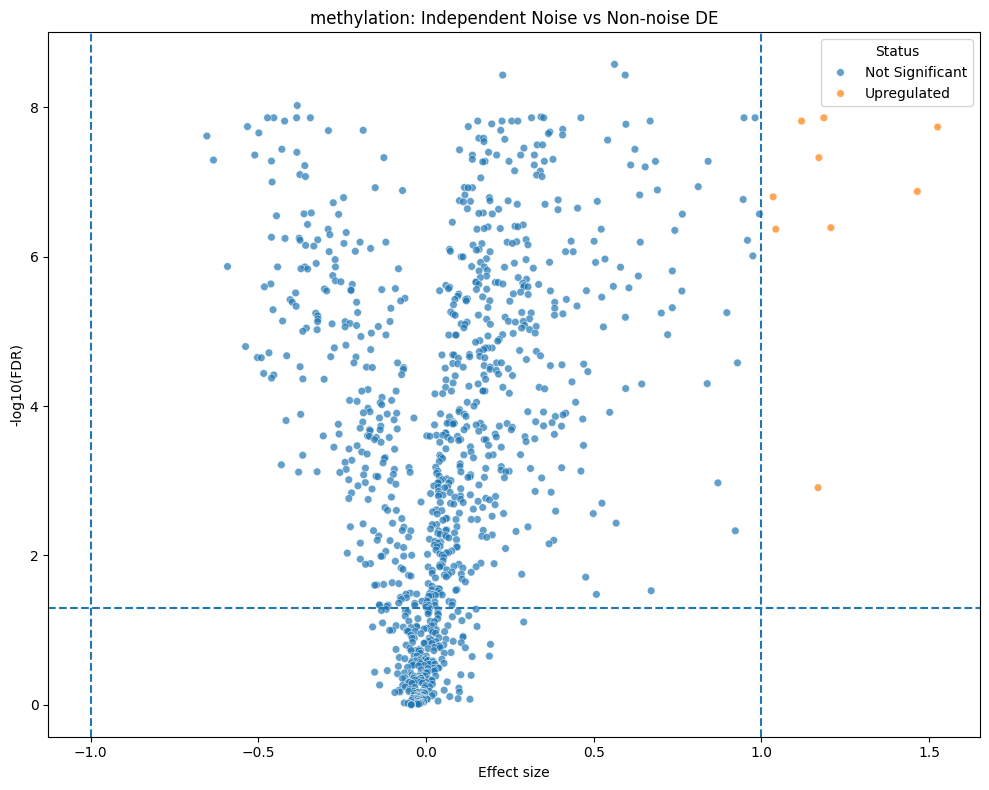

In [81]:
# ============================================================
# STEP 17 : INDEPENDENT VOLCANO PLOT
# ============================================================

plt.figure(
    figsize=(10, 8)
)

plot_df = statistics.copy()

plot_df["neg_log10_FDR"] = (
    -np.log10(
        plot_df["FDR"] + 1e-300
    )
)

sns.scatterplot(
    data=plot_df,
    x="Effect_Size",
    y="neg_log10_FDR",
    hue="Status",
    alpha=0.7,
    s=30
)

plt.axvline(
    x=LOG2FC_THRESHOLD,
    linestyle="--"
)

plt.axvline(
    x=-LOG2FC_THRESHOLD,
    linestyle="--"
)

plt.axhline(
    y=-np.log10(FDR_THRESHOLD),
    linestyle="--"
)

plt.xlabel(
    "Effect size"
)

plt.ylabel(
    "-log10(FDR)"
)

plt.title(
    f"{MODALITY}: Independent Noise vs Non-noise DE"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "M3_Independent_Volcano.png"
    ),
    dpi=300
)

plt.show()

# STEP AF — Heatmap

Selected genes: 9


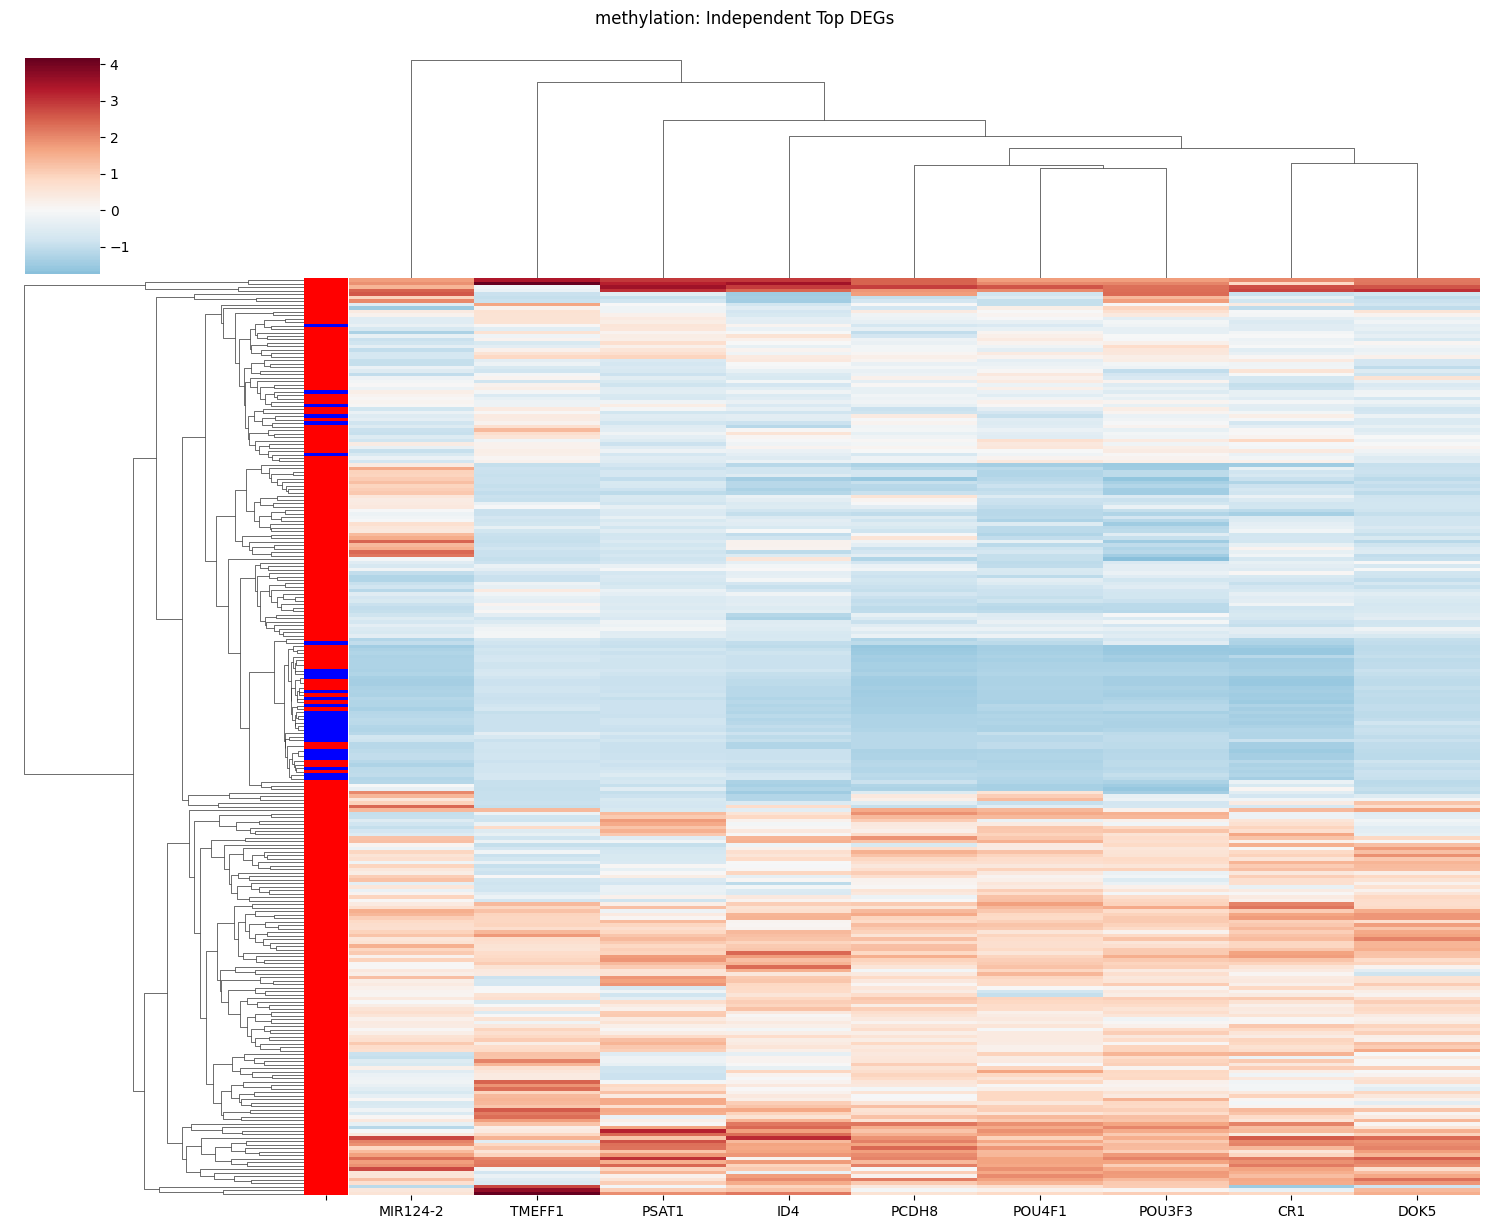

In [82]:
# ============================================================
# STEP 18 : INDEPENDENT TOP-GENE HEATMAP
# ============================================================

top_genes = (
    DEGs
    .head(TOP_N_GENES)
    ["Gene"]
    .tolist()
)

print(
    "Selected genes:",
    len(top_genes)
)

heatmap_expression = (
    inference_expression[
        top_genes
    ]
    .copy()
)

heatmap_groups = np.where(
    inference_labels == -1,
    "Noise",
    "Non-noise"
)

# ------------------------------------------------------------
# Gene-wise z-score
# ------------------------------------------------------------

heatmap_z = (
    heatmap_expression -
    heatmap_expression.mean(axis=0)
) / (
    heatmap_expression.std(axis=0)
    .replace(0, 1)
)

# ------------------------------------------------------------
# Annotation
# ------------------------------------------------------------

row_colors = pd.Series(
    heatmap_groups,
    index=heatmap_expression.index
)

# ------------------------------------------------------------
# Clustered heatmap
# ------------------------------------------------------------

sns.clustermap(
    heatmap_z,

    cmap="RdBu_r",

    center=0,

    row_colors=row_colors.map({
        "Noise": "red",
        "Non-noise": "blue"
    }),

    figsize=(15, 12),

    xticklabels=True,

    yticklabels=False,

    method="average",

    metric="euclidean"
)

plt.suptitle(
    f"{MODALITY}: Independent Top DEGs",
    y=1.02
)

plt.show()

# STEP AG — Biological interpretation

In [83]:
# ============================================================
# STEP 19 : KNOWN CANCER-ASSOCIATED GENE ANNOTATION
#            Expanded for DNA Methylation Analysis
# ============================================================

important_genes = {

    # --------------------------------------------------------
    # 1. Tumor Suppressor Genes
    # --------------------------------------------------------
    "Tumor Suppressor": [

        "TP53",
        "RB1",
        "CDKN2A",
        "CDKN2B",
        "PTEN",
        "APC",
        "RASSF1",
        "RASSF1A",
        "RASSF2",
        "VHL",

        "BRCA1",
        "BRCA2",

        "DOK5",
        "RUNX3",
        "FHIT",
        "SOCS1",
        "SOCS3",

        "CDH1",
        "CDH13",
        "CADM1",
        "OPCML",
        "PCDH10",
        "PCDH20",

        "TIMP3",
        "THBS1",
        "TFPI2",

        "SFRP1",
        "SFRP2",
        "WIF1",
        "DKK3"
    ],


    # --------------------------------------------------------
    # 2. DNA Repair / Genome Stability
    # --------------------------------------------------------
    "DNA Repair": [

        "MGMT",
        "MLH1",
        "MSH2",
        "MSH6",
        "PMS2",

        "BRCA1",
        "BRCA2",

        "ATM",
        "ATR",
        "CHEK1",
        "CHEK2",

        "FANCF",
        "FANCC",
        "FANCD2",

        "RAD51",
        "RAD51C",

        "ERCC1",
        "ERCC2",
        "ERCC5",

        "XRCC1",
        "PARP1"
    ],


    # --------------------------------------------------------
    # 3. Cell Cycle Regulation
    # --------------------------------------------------------
    "Cell Cycle": [

        "CDKN2A",
        "CDKN2B",
        "CDKN1A",
        "CDKN1B",

        "RB1",

        "CCND1",
        "CCND2",
        "CCND3",

        "CCNE1",
        "CCNE2",

        "CDK2",
        "CDK4",
        "CDK6",

        "E2F1",
        "E2F3",

        "TP53"
    ],


    # --------------------------------------------------------
    # 4. Wnt / Beta-Catenin Signaling
    # --------------------------------------------------------
    "Wnt Signaling": [

        "APC",

        "SFRP1",
        "SFRP2",
        "SFRP4",
        "SFRP5",

        "WIF1",

        "DKK1",
        "DKK2",
        "DKK3",

        "AXIN1",
        "AXIN2",

        "CTNNB1",

        "RUNX3",

        "CDH1"
    ],


    # --------------------------------------------------------
    # 5. Apoptosis
    # --------------------------------------------------------
    "Apoptosis": [

        "DAPK1",
        "CASP8",
        "CASP3",
        "CASP7",
        "CASP9",

        "BCL2",
        "BCL2L11",

        "BAX",
        "BAK1",

        "PYCARD",

        "TP53",
        "TP73",

        "FAS",
        "FASLG",

        "XIAP"
    ],


    # --------------------------------------------------------
    # 6. EMT / Cell Adhesion / Metastasis
    # --------------------------------------------------------
    "EMT": [

        "CDH1",
        "CDH13",
        "CDH11",

        "TWIST1",
        "TWIST2",

        "SNAI1",
        "SNAI2",

        "ZEB1",
        "ZEB2",

        "VIM",

        "EPCAM",

        "ITGA6",
        "ITGB1",

        "MMP2",
        "MMP9"
    ],


    # --------------------------------------------------------
    # 7. PI3K / AKT / MTOR Signaling
    # --------------------------------------------------------
    "PI3K_AKT": [

        "PTEN",

        "PIK3CA",
        "PIK3CB",

        "AKT1",
        "AKT2",

        "MTOR",

        "TSC1",
        "TSC2",

        "PDPK1",

        "FOXO1",
        "FOXO3",

        "RICTOR",

        "DOK5"
    ],


    # --------------------------------------------------------
    # 8. RAS / MAPK Signaling
    # --------------------------------------------------------
    "RAS_MAPK": [

        "KRAS",
        "NRAS",
        "HRAS",

        "BRAF",

        "RAF1",

        "MAP2K1",
        "MAP2K2",

        "MAPK1",
        "MAPK3",

        "NF1",

        "DOK5"
    ],


    # --------------------------------------------------------
    # 9. Immune Regulation / Immune Checkpoints
    # --------------------------------------------------------
    "Immune Regulation": [

        "PDCD1",
        "CD274",

        "PDCD1LG2",

        "CTLA4",

        "LAG3",
        "HAVCR2",
        "TIGIT",

        "IFNG",

        "CXCL9",
        "CXCL10",
        "CXCL11",

        "IDO1",

        "FOXP3",

        "STAT1",
        "STAT3"
    ],


    # --------------------------------------------------------
    # 10. Cancer Epigenetic / DNA Methylation Markers
    # --------------------------------------------------------
    "Cancer Epigenetic Markers": [

        # ---- Classical methylation biomarkers ----
        "GSTP1",
        "SEPT9",
        "SHOX2",

        "RARB",
        "SOX17",

        "GATA4",
        "GATA5",

        "CDH13",

        "MGMT",
        "MLH1",

        # ---- Frequently methylated tumor suppressors ----
        "RASSF1",
        "RASSF2",

        "CDKN2A",
        "CDKN2B",

        "APC",
        "RUNX3",

        "DAPK1",
        "FHIT",

        "SOCS1",
        "SOCS3",

        "TIMP3",
        "TFPI2",

        "OPCML",
        "CADM1",
        "PCDH10",

        # ---- Wnt pathway methylation ----
        "SFRP1",
        "SFRP2",
        "SFRP4",
        "SFRP5",

        "WIF1",

        "DKK3",

        # ---- Developmental / differentiation genes ----
        "HOXA9",
        "HOXA10",
        "HOXA11",

        "SOX1",
        "SOX2",
        "SOX17",

        "PAX1",
        "PAX5",

        # ---- Hormone / receptor-associated methylation ----
        "ESR1",
        "ESR2",

        "PGR",

        "AR",

        "RARβ",
        "RARB",

        # ---- Cell adhesion / metastasis methylation ----
        "CDH1",
        "CDH13",
        "CADM1",

        # ---- Additional cancer methylation biomarkers ----
        "NDRG4",
        "BMP3",
        "SDC2",

        "VIM",

        "IGFBP3",
        "IGFBP7",

        "TMS1",
        "PYCARD",

        # ---- miRNA gene affected by DNA methylation ----
        "MIR-124-2",
        "MIR124-2"
    ],


    # --------------------------------------------------------
    # 11. Angiogenesis
    # --------------------------------------------------------
    "Angiogenesis": [

        "VEGFA",
        "VEGFB",
        "VEGFC",

        "FLT1",
        "KDR",

        "ANGPT1",
        "ANGPT2",

        "HIF1A",

        "EPAS1",

        "PDGFB"
    ],


    # --------------------------------------------------------
    # 12. TGF-Beta Signaling
    # --------------------------------------------------------
    "TGF_Beta": [

        "TGFB1",
        "TGFBR1",
        "TGFBR2",

        "SMAD2",
        "SMAD3",
        "SMAD4",

        "SMAD7",

        "RUNX3",

        "BMP3"
    ],


    # --------------------------------------------------------
    # 13. JAK / STAT Signaling
    # --------------------------------------------------------
    "JAK_STAT": [

        "JAK1",
        "JAK2",
        "JAK3",

        "STAT1",
        "STAT2",
        "STAT3",
        "STAT5A",
        "STAT5B",

        "SOCS1",
        "SOCS3"
    ],


    # --------------------------------------------------------
    # 14. Hormone Receptor / Cancer-Related Genes
    # --------------------------------------------------------
    "Hormone_Receptor": [

        "ESR1",
        "ESR2",

        "PGR",

        "AR",

        "RARB",

        "RXRA",

        "IGF1R",

        "IGF2"
    ]
}


# ============================================================
# PERFORM GENE ANNOTATION
# ============================================================

biological_hits = []


for pathway, genes in important_genes.items():

    for gene in genes:

        # ----------------------------------------------------
        # Match gene names robustly
        # ----------------------------------------------------
        gene_upper = str(gene).upper().strip()

        gene_mask = (
            DEGs["Gene"]
            .astype(str)
            .str.upper()
            .str.strip()
            .str.startswith(gene_upper)
        )

        hits = DEGs.loc[gene_mask]

        if len(hits) > 0:

            temp = hits.copy()

            temp["Known_Biological_Category"] = pathway
            temp["Known_Cancer_Gene"] = gene

            biological_hits.append(temp)


# ============================================================
# COMBINE RESULTS
# ============================================================

if biological_hits:

    biological_hits = pd.concat(
        biological_hits,
        ignore_index=True
    )

    # --------------------------------------------------------
    # Remove exact duplicate annotation rows
    # while preserving genes belonging to multiple pathways
    # --------------------------------------------------------
    biological_hits = biological_hits.drop_duplicates(
        subset=[
            "Gene",
            "Known_Biological_Category",
            "Known_Cancer_Gene"
        ]
    )

    # --------------------------------------------------------
    # Sort by FDR if available
    # --------------------------------------------------------
    if "FDR" in biological_hits.columns:

        biological_hits = (
            biological_hits
            .sort_values(
                by="FDR",
                ascending=True
            )
            .reset_index(drop=True)
        )

else:

    biological_hits = pd.DataFrame()


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("KNOWN CANCER-ASSOCIATED GENE ANNOTATION")
print("=" * 80)

if not biological_hits.empty:

    print(
        f"\nTotal annotated records: "
        f"{len(biological_hits)}"
    )

    print(
        f"Unique genes identified: "
        f"{biological_hits['Gene'].nunique()}"
    )

    print("\nCategory-wise counts:")

    print(
        biological_hits[
            "Known_Biological_Category"
        ]
        .value_counts()
    )

    print("\nAnnotated genes:")

    print(
        biological_hits[
            [
                "Gene",
                "Known_Cancer_Gene",
                "Known_Biological_Category"
            ]
        ]
        .to_string(index=False)
    )

else:

    print(
        "\nNo known cancer-associated genes "
        "were detected in the DEGs table."
    )


# ============================================================
# SAVE RESULTS
# ============================================================

output_file = os.path.join(
    OUTPUT_DIR,
    "Known_Cancer_Gene_Annotation.csv"
)

biological_hits.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 80)
print("Annotation saved to:")
print(output_file)
print("=" * 80)


KNOWN CANCER-ASSOCIATED GENE ANNOTATION

Total annotated records: 4
Unique genes identified: 2

Category-wise counts:
Known_Biological_Category
Cancer Epigenetic Markers    1
Tumor Suppressor             1
PI3K_AKT                     1
RAS_MAPK                     1
Name: count, dtype: int64

Annotated genes:
    Gene Known_Cancer_Gene Known_Biological_Category
MIR124-2          MIR124-2 Cancer Epigenetic Markers
    DOK5              DOK5          Tumor Suppressor
    DOK5              DOK5                  PI3K_AKT
    DOK5              DOK5                  RAS_MAPK

Annotation saved to:
/content/methylation_Reviewer_Corrected_Results/Known_Cancer_Gene_Annotation.csv


# STEP AH — GO enrichment

In [84]:
# ============================================================
# STEP 20 : GO ENRICHMENT
# ============================================================
!pip install gseapy
import gseapy as gp

gene_list = (
    DEGs["Gene"]
    .astype(str)
    .str.split("|")
    .str[0]
    .drop_duplicates()
    .tolist()
)

print(
    "Genes for GO:",
    len(gene_list)
)

go_results = gp.enrichr(
    gene_list=gene_list,

    gene_sets=[
        "GO_Biological_Process_2026",
        "GO_Molecular_Function_2026",
        "GO_Cellular_Component_2026"
    ],

    organism="human",

    outdir=None,

    no_plot=True,

    cutoff=1.0
)

if not go_results.results.empty:

    go_table = go_results.results.copy()

    go_table.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "M3_GO_Enrichment.csv"
        ),
        index=False
    )

    print(
        go_table.head(20)
    )

else:

    print(
        "No enriched GO terms."
    )

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 15.8 MB/s eta 0:00:00
Genes for GO: 9
                      Gene_set  \
0   GO_Biological_Process_2026   
1   GO_Biological_Process_2026   
2   GO_Biological_Process_2026   
3   GO_Biological_Process_2026   
4   GO_Biological_Process_2026   
5   GO_Biological_Process_2026   
6   GO_Biological_Process_2026   
7   GO_Biological_Process_2026   
8   GO_Biological_Process_2026   
9   GO_Biological_Process_2026   
10  GO_Biological_Process_2026   
11  GO_Biological_Process_2026   
12  GO_Biological_Process_2026   
13  GO_Biological_Process_2026   
14  GO_Biological_Process_2026   
15  GO_Biological_Process_2026   
16  GO_Biological_Process_2026   
17  GO_Biological_Process_2026   
18  GO_Biological_Process_2026   
19  GO_Biological_Process_2026   

                                                 Term Overlap   P-value  \
0   Negative Regulation of Programmed Cell Death (...   3/410  0.000655   
1   Metanephric Distal Tubule Developm

# STEP AI — KEGG

In [85]:
# ============================================================
# STEP 21 : KEGG ENRICHMENT
# ============================================================

kegg_results = gp.enrichr(
    gene_list=gene_list,

    gene_sets="KEGG_2021_Human",

    organism="human",

    outdir=None,

    no_plot=True,

    cutoff=1.0
)

kegg_table = kegg_results.results.copy()

kegg_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "M3_KEGG_Enrichment.csv"
    ),
    index=False
)

print(
    kegg_table.head(20)
)

           Gene_set                                               Term  \
0   KEGG_2021_Human                              Vitamin B6 metabolism   
1   KEGG_2021_Human           Glycine, serine and threonine metabolism   
2   KEGG_2021_Human                 Cysteine and methionine metabolism   
3   KEGG_2021_Human                                            Malaria   
4   KEGG_2021_Human                                      Legionellosis   
5   KEGG_2021_Human                                      Leishmaniasis   
6   KEGG_2021_Human                Complement and coagulation cascades   
7   KEGG_2021_Human                         TGF-beta signaling pathway   
8   KEGG_2021_Human                         Hematopoietic cell lineage   
9   KEGG_2021_Human  Signaling pathways regulating pluripotency of ...   
10  KEGG_2021_Human                                       Tuberculosis   
11  KEGG_2021_Human            Neutrophil extracellular trap formation   
12  KEGG_2021_Human                   

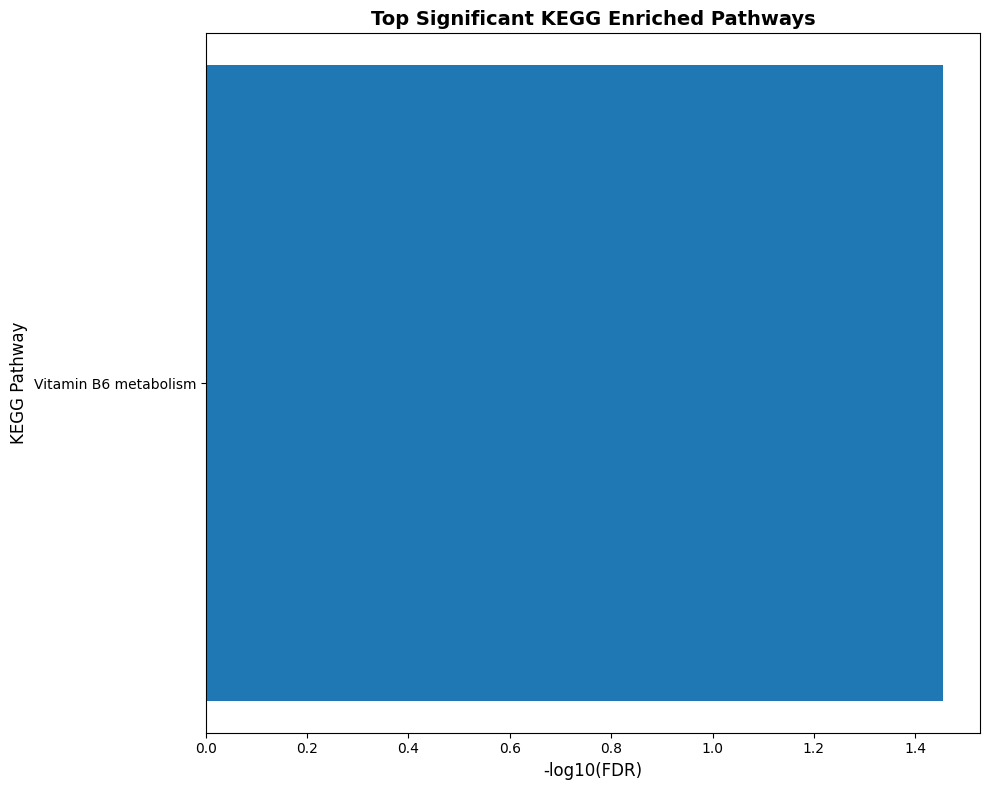


KEGG pathway visualization saved to:
/content/methylation_Reviewer_Corrected_Results/M3_KEGG_Enrichment_Barplot.png


In [86]:
# ============================================================
# STEP 21.1 : KEGG PATHWAY VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Check whether KEGG results are available
# ------------------------------------------------------------

if not kegg_table.empty:

    # --------------------------------------------------------
    # Select significant pathways
    # --------------------------------------------------------

    plot_df = kegg_table.copy()

    # Convert adjusted P-value to numeric
    plot_df["Adjusted P-value"] = pd.to_numeric(
        plot_df["Adjusted P-value"],
        errors="coerce"
    )

    # Remove invalid values
    plot_df = plot_df.dropna(
        subset=["Adjusted P-value"]
    )

    # Keep statistically significant pathways
    significant_df = plot_df[
        plot_df["Adjusted P-value"] < 0.05
    ].copy()

    # --------------------------------------------------------
    # If no significant pathway exists,
    # visualize top pathways by adjusted P-value
    # --------------------------------------------------------

    if significant_df.empty:

        print(
            "\nNo KEGG pathways reached FDR < 0.05."
        )

        significant_df = (
            plot_df
            .sort_values(
                "Adjusted P-value",
                ascending=True
            )
            .head(20)
            .copy()
        )

        plot_title = (
            "Top KEGG Enriched Pathways"
        )

    else:

        significant_df = (
            significant_df
            .sort_values(
                "Adjusted P-value",
                ascending=True
            )
            .head(20)
            .copy()
        )

        plot_title = (
            "Top Significant KEGG Enriched Pathways"
        )


    # --------------------------------------------------------
    # Calculate -log10(FDR)
    # --------------------------------------------------------

    significant_df["-log10(FDR)"] = (
        -np.log10(
            significant_df["Adjusted P-value"]
        )
    )


    # --------------------------------------------------------
    # Sort for horizontal bar plot
    # --------------------------------------------------------

    significant_df = (
        significant_df
        .sort_values(
            "-log10(FDR)",
            ascending=True
        )
    )


    # --------------------------------------------------------
    # Create pathway labels
    # --------------------------------------------------------

    pathway_labels = (
        significant_df["Term"]
        .astype(str)
    )


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(
        figsize=(10, 8)
    )

    plt.barh(
        pathway_labels,
        significant_df["-log10(FDR)"]
    )

    plt.xlabel(
        "-log10(FDR)",
        fontsize=12
    )

    plt.ylabel(
        "KEGG Pathway",
        fontsize=12
    )

    plt.title(
        plot_title,
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()


    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    kegg_plot_file = os.path.join(
        OUTPUT_DIR,
        "M3_KEGG_Enrichment_Barplot.png"
    )

    plt.savefig(
        kegg_plot_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "\nKEGG pathway visualization saved to:"
    )

    print(kegg_plot_file)


else:

    print(
        "\nNo KEGG enrichment results available "
        "for visualization."
    )

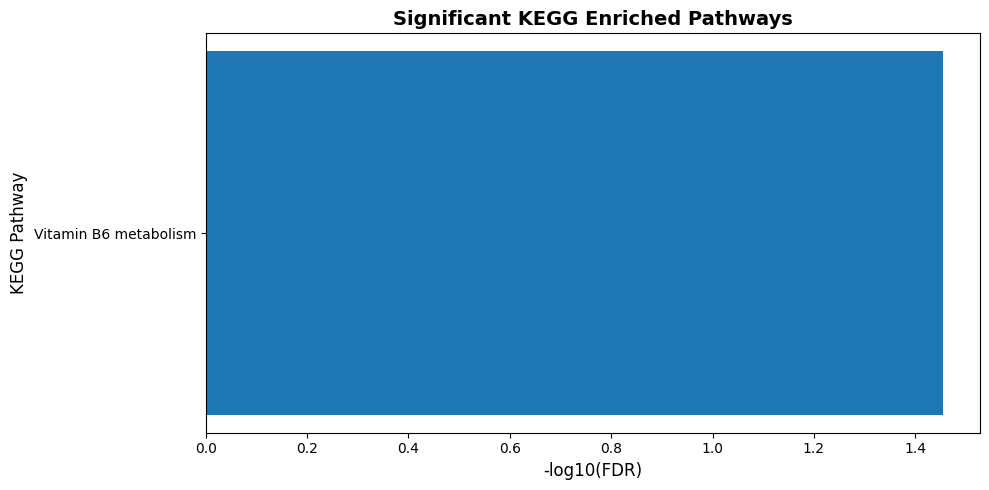


KEGG visualization saved to:
/content/methylation_Reviewer_Corrected_Results/M3_KEGG_Enrichment_Barplot.png


In [87]:
# ============================================================
# STEP 21.1 : KEGG ENRICHMENT VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

if not kegg_table.empty:

    plot_df = kegg_table.copy()

    # Convert FDR to numeric
    plot_df["Adjusted P-value"] = pd.to_numeric(
        plot_df["Adjusted P-value"],
        errors="coerce"
    )

    # Remove invalid values
    plot_df = plot_df.dropna(
        subset=["Adjusted P-value"]
    )

    # --------------------------------------------------------
    # Select significant pathways
    # --------------------------------------------------------

    significant_df = plot_df[
        plot_df["Adjusted P-value"] < 0.05
    ].copy()

    if not significant_df.empty:

        # Sort by FDR
        significant_df = (
            significant_df
            .sort_values(
                "Adjusted P-value",
                ascending=True
            )
        )

        # Calculate -log10(FDR)
        significant_df["-log10(FDR)"] = (
            -np.log10(
                significant_df["Adjusted P-value"]
            )
        )

        # ----------------------------------------------------
        # Plot
        # ----------------------------------------------------

        plt.figure(
            figsize=(10, 5)
        )

        plt.barh(
            significant_df["Term"],
            significant_df["-log10(FDR)"]
        )

        plt.xlabel(
            "-log10(FDR)",
            fontsize=12
        )

        plt.ylabel(
            "KEGG Pathway",
            fontsize=12
        )

        plt.title(
            "Significant KEGG Enriched Pathways",
            fontsize=14,
            fontweight="bold"
        )

        plt.tight_layout()

        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------

        kegg_plot_file = os.path.join(
            OUTPUT_DIR,
            "M3_KEGG_Enrichment_Barplot.png"
        )

        plt.savefig(
            kegg_plot_file,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(
            "\nKEGG visualization saved to:"
        )

        print(kegg_plot_file)

    else:

        print(
            "\nNo KEGG pathways reached "
            "FDR < 0.05."
        )

else:

    print(
        "\nNo KEGG enrichment results available."
    )

# PART AJ — M4: competing non-deep baseline


PCA + LOF
PCA + Isolation Forest
DAE + HDBSCAN

# STEP 22 — PCA + LOF

In [88]:
# ============================================================
# STEP 22 : BASELINE 1 — PCA + LOF
# ============================================================

from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination="auto"
)

lof_labels = lof.fit_predict(
    X_test_pca
)

lof_noise = (
    lof_labels == -1
)

print("=" * 80)

print("PCA + LOF")

print(
    "Noise:",
    lof_noise.sum()
)

print(
    "Noise %:",
    lof_noise.mean() * 100
)

PCA + LOF
Noise: 3
Noise %: 2.272727272727273


# STEP AK — Isolation Forest

In [89]:
# ============================================================
# STEP 23 : BASELINE 2 — PCA + ISOLATION FOREST
# ============================================================

from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=300,
    random_state=SEED,
    contamination="auto"
)

iso_labels = iso.fit_predict(
    X_test_pca
)

iso_noise = (
    iso_labels == -1
)

print("=" * 80)

print("PCA + Isolation Forest")

print(
    "Noise:",
    iso_noise.sum()
)

print(
    "Noise %:",
    iso_noise.mean() * 100
)

PCA + Isolation Forest
Noise: 14
Noise %: 10.606060606060606


# STEP AL — Baseline comparison

In [90]:
# ============================================================
# STEP 24 : M4 BASELINE COMPARISON
# ============================================================

baseline_results = pd.DataFrame({

    "Method": [
        f"PCA-{matched_rank} + HDBSCAN",
        f"PCA-{matched_rank} + LOF",
        f"PCA-{matched_rank} + Isolation Forest"
    ],

    "Noise_Samples": [
        raw_summary["Noise_Samples"],
        int(lof_noise.sum()),
        int(iso_noise.sum())
    ],

    "Noise_Percent": [
        raw_summary["Noise_Percent"],
        lof_noise.mean() * 100,
        iso_noise.mean() * 100
    ],

    "Clusters_K": [
        raw_summary["Clusters_K"],
        np.nan,
        np.nan
    ]
})

print(
    baseline_results
)

baseline_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "M4_Baseline_Outlier_Comparison.csv"
    ),
    index=False
)

                      Method  Noise_Samples  Noise_Percent  Clusters_K
0           PCA-14 + HDBSCAN             74      56.060606         2.0
1               PCA-14 + LOF              3       2.272727         NaN
2  PCA-14 + Isolation Forest             14      10.606061         NaN


# STEP AM — M4 synthetic technical-noise experiment

We can create controlled noise:

Clean expression
      ↓
inject Gaussian technical noise
      ↓
DAE
      ↓
outlier detection
      ↓
measure recovery

In [91]:
# ============================================================
# STEP 25 : M4 SYNTHETIC TECHNICAL NOISE
# ============================================================

def inject_gaussian_noise(
    X,
    noise_level,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )

    noise = rng.normal(
        loc=0.0,
        scale=noise_level,
        size=X.shape
    )

    return X + noise

In [92]:
# ============================================================
# STEP 25.1 : TEST MULTIPLE NOISE LEVELS
# ============================================================

noise_levels = [
    0.10,
    0.25,
    0.50,
    1.00
]

simulation_results = []

for level in noise_levels:

    X_noisy = inject_gaussian_noise(
        X_test_scaled,
        noise_level=level,
        random_state=SEED
    )

    reconstruction = dae_mse.predict(
        X_noisy,
        verbose=0
    )

    residual = np.mean(
        np.abs(
            X_noisy -
            reconstruction
        ),
        axis=1
    )

    simulation_results.append({

        "Noise_Level":
            level,

        "Mean_Residual":
            residual.mean(),

        "Median_Residual":
            np.median(residual),

        "Max_Residual":
            residual.max()

    })

simulation_results = pd.DataFrame(
    simulation_results
)

print(
    simulation_results
)

simulation_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "M4_Synthetic_Technical_Noise.csv"
    ),
    index=False
)

   Noise_Level  Mean_Residual  Median_Residual  Max_Residual
0         0.10       0.420496         0.415140      1.022906
1         0.25       0.467771         0.456432      1.047071
2         0.50       0.594221         0.578967      1.119797
3         1.00       0.923672         0.904723      1.351321


# PART AN — M4: HDBSCAN Noise vs Dataset Labels
PART AN.1 — Configuration

In [93]:
# ============================================================
# PART AN.1 — M4 CONFIGURATION
# HDBSCAN Noise vs Dataset Labels
# ============================================================

import os
import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

LABEL_FILE = "/content/labels.csv"

RESULTS_DIR = "/content/M4_Label_Noise_Analysis"
os.makedirs(RESULTS_DIR, exist_ok=True)

LABEL_COLUMN = 0

NOISE_LABEL = -1

ALPHA = 0.05

print("=" * 70)
print("PART AN.1 — M4 CONFIGURATION")
print("=" * 70)

print("Label file:", LABEL_FILE)
print("Results directory:", RESULTS_DIR)
print("Significance level:", ALPHA)

PART AN.1 — M4 CONFIGURATION
Label file: /content/labels.csv
Results directory: /content/M4_Label_Noise_Analysis
Significance level: 0.05


# PART AN.2 — Load labels.csv

In [94]:
# ============================================================
# PART AN.2 — LOAD DATASET LABELS
# ============================================================

labels_df = pd.read_csv(
    LABEL_FILE,
    header=None
)

labels = labels_df.iloc[:, LABEL_COLUMN].copy()

# Convert to numeric
labels = pd.to_numeric(
    labels,
    errors="coerce"
)

# Check missing labels
missing_labels = labels.isna().sum()

if missing_labels > 0:
    raise ValueError(
        f"Found {missing_labels} missing labels in labels.csv."
    )

# Convert to integer
labels = labels.astype(int)

print("=" * 70)
print("PART AN.2 — LABEL INFORMATION")
print("=" * 70)

print("Number of labels:", len(labels))
print("\nLabel distribution:")
print(labels.value_counts().sort_index())

print("\nUnique labels:")
print(sorted(labels.unique()))

PART AN.2 — LABEL INFORMATION
Number of labels: 875

Label distribution:
0
0    115
1    131
2     46
3    436
4    147
Name: count, dtype: int64

Unique labels:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


# PART AN.3 — Validate Labels Against Your Dataset

In [95]:
# ============================================================
# PART AN.3 — VALIDATE LABEL LENGTH
# ============================================================

EXPECTED_SAMPLES = 875

print("=" * 70)
print("PART AN.3 — LABEL/DATASET VALIDATION")
print("=" * 70)

if len(labels) != EXPECTED_SAMPLES:
    raise ValueError(
        f"Expected {EXPECTED_SAMPLES} labels, "
        f"but labels.csv contains {len(labels)} labels."
    )

print("✓ Label count:", len(labels))
print("✓ Expected samples:", EXPECTED_SAMPLES)
print("✓ Label count matches dataset.")

PART AN.3 — LABEL/DATASET VALIDATION
✓ Label count: 875
✓ Expected samples: 875
✓ Label count matches dataset.


# PART AN.4 — Convert HDBSCAN Labels to Noise/Clustered

In [96]:
# ============================================================
# PART AN.4 — HDBSCAN NOISE/CLUSTERED CONVERSION
# ============================================================

def create_noise_status(hdbscan_labels):
    """
    Convert HDBSCAN cluster labels into:
        Noise    -> -1
        Clustered -> any cluster label >= 0
    """

    hdbscan_labels = np.asarray(hdbscan_labels)

    noise_status = np.where(
        hdbscan_labels == NOISE_LABEL,
        "Noise",
        "Clustered"
    )

    return noise_status

# PART AN.5 — Cramér's V Function

In [97]:
# ============================================================
# PART AN.5 — CRAMÉR'S V
# ============================================================

def cramers_v(contingency_table):
    """
    Calculate Cramér's V from a contingency table.
    """

    chi2, p, dof, expected = chi2_contingency(
        contingency_table
    )

    n = contingency_table.to_numpy().sum()

    r, k = contingency_table.shape

    denominator = min(
        k - 1,
        r - 1
    )

    if denominator <= 0 or n == 0:
        return np.nan

    return np.sqrt(
        (chi2 / n) / denominator
    )

# PART AN.6 — Standardized Residuals Function

In [98]:
# ============================================================
# PART AN.6 — STANDARDIZED RESIDUALS
# ============================================================

def standardized_residuals(contingency_table):
    """
    Calculate Pearson standardized residuals.

    Residual > 0:
        observed count > expected count

    Residual < 0:
        observed count < expected count
    """

    chi2, p, dof, expected = chi2_contingency(
        contingency_table
    )

    observed = contingency_table.to_numpy(dtype=float)

    row_totals = observed.sum(axis=1, keepdims=True)
    col_totals = observed.sum(axis=0, keepdims=True)
    total = observed.sum()

    expected_prob = (
        expected / total
    )

    row_prob = row_totals / total
    col_prob = col_totals / total

    denominator = np.sqrt(
        expected
        * (1 - row_prob)
        * (1 - col_prob)
    )

    residuals = (
        observed - expected
    ) / denominator

    return pd.DataFrame(
        residuals,
        index=contingency_table.index,
        columns=contingency_table.columns
    )

# PART AN.7 — Fisher's Exact Test Helper

In [99]:
# ============================================================
# PART AN.7 — FISHER'S EXACT TEST FOR EACH LABEL
# ============================================================

def fisher_tests_by_label(labels, noise_status):

    temp = pd.DataFrame({
        "Label": labels.values,
        "Noise_Status": noise_status
    })

    results = []

    unique_labels = sorted(
        temp["Label"].unique()
    )

    for label in unique_labels:

        temp["Target_Label"] = (
            temp["Label"] == label
        )

        table = pd.crosstab(
            temp["Target_Label"],
            temp["Noise_Status"]
        )

        # Ensure 2x2 structure
        for row in [False, True]:
            if row not in table.index:
                table.loc[row] = 0

        for col in ["Clustered", "Noise"]:
            if col not in table.columns:
                table[col] = 0

        table = table.loc[
            [False, True],
            ["Clustered", "Noise"]
        ]

        odds_ratio, p_value = fisher_exact(
            table
        )

        results.append({
            "Label": label,
            "Odds_Ratio": odds_ratio,
            "Fisher_P_Value": p_value
        })

    return pd.DataFrame(results)

# PART AN.8 — Main M4 Analysis Function

In [100]:

# ============================================================
# PART AN.8 — M4 LABEL–NOISE ANALYSIS FUNCTION
#                Methylation / mRNA / miRNA
#
# Supports:
#   - Full-sample HDBSCAN labels
#   - Held-out/inference HDBSCAN labels
#   - Automatic sample-index alignment
#
# Statistical tests:
#   1. Chi-square
#   2. Cramér's V
#   3. Adjusted standardized Pearson residuals
#   4. Label-wise Fisher exact tests
#   5. Benjamini-Hochberg FDR
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests


# ============================================================
# Cramér's V
# ============================================================

def cramers_v(contingency_table):

    chi2, _, _, _ = chi2_contingency(
        contingency_table
    )

    n = contingency_table.to_numpy().sum()

    r, k = contingency_table.shape

    if n <= 1:
        return np.nan

    phi2 = chi2 / n

    phi2_corrected = max(
        0,
        phi2 -
        ((k - 1) * (r - 1)) / (n - 1)
    )

    r_corrected = (
        r -
        ((r - 1) ** 2) / (n - 1)
    )

    k_corrected = (
        k -
        ((k - 1) ** 2) / (n - 1)
    )

    denominator = min(
        k_corrected - 1,
        r_corrected - 1
    )

    if denominator <= 0:
        return np.nan

    return np.sqrt(
        phi2_corrected / denominator
    )


# ============================================================
# M4 ANALYSIS
# ============================================================

def run_m4_label_noise_analysis(
    modality,
    hdbscan_labels,
    dataset_labels,
    sample_indices=None
):

    print("\n" + "=" * 80)
    print(
        f"M4 LABEL–NOISE ANALYSIS — {modality}"
    )
    print("=" * 80)

    # ========================================================
    # Convert inputs
    # ========================================================

    dataset_labels = pd.Series(
        dataset_labels
    ).reset_index(drop=True)

    hdbscan_labels = pd.Series(
        hdbscan_labels
    ).reset_index(drop=True)

    print("\nInput dimensions")
    print("-" * 80)

    print(
        f"Dataset labels : {len(dataset_labels)}"
    )

    print(
        f"HDBSCAN labels : {len(hdbscan_labels)}"
    )

    # ========================================================
    # FULL DATASET
    # ========================================================

    if sample_indices is None:

        if len(hdbscan_labels) != len(dataset_labels):

            raise ValueError(
                f"\n{modality}: Length mismatch.\n\n"
                f"HDBSCAN labels = "
                f"{len(hdbscan_labels)}\n"
                f"Dataset labels = "
                f"{len(dataset_labels)}\n\n"
                "HDBSCAN appears to have been "
                "generated on a subset.\n"
                "Provide the corresponding "
                "sample_indices."
            )

        aligned_hdbscan = (
            hdbscan_labels.copy()
        )

        aligned_dataset = (
            dataset_labels.copy()
        )

        aligned_indices = np.arange(
            len(dataset_labels)
        )

    # ========================================================
    # SUBSET / INFERENCE DATASET
    # ========================================================

    else:

        sample_indices = np.asarray(
            sample_indices
        )

        if len(hdbscan_labels) != len(sample_indices):

            raise ValueError(
                f"\n{modality}: HDBSCAN labels and "
                f"sample_indices mismatch.\n\n"
                f"HDBSCAN labels = "
                f"{len(hdbscan_labels)}\n"
                f"sample_indices = "
                f"{len(sample_indices)}"
            )

        if np.any(sample_indices < 0):

            raise ValueError(
                f"{modality}: Negative sample index detected."
            )

        if np.any(
            sample_indices >= len(dataset_labels)
        ):

            raise ValueError(
                f"{modality}: sample_indices contains "
                "an index outside the dataset."
            )

        aligned_hdbscan = (
            hdbscan_labels.copy()
        )

        aligned_dataset = (
            dataset_labels.iloc[
                sample_indices
            ]
            .reset_index(drop=True)
        )

        aligned_indices = sample_indices

        print("\nSubset alignment enabled.")
        print(
            f"Aligned samples : "
            f"{len(aligned_hdbscan)}"
        )

    # ========================================================
    # Remove missing observations
    # ========================================================

    valid_mask = (
        aligned_hdbscan.notna()
        &
        aligned_dataset.notna()
    )

    aligned_hdbscan = (
        aligned_hdbscan[
            valid_mask
        ]
        .reset_index(drop=True)
    )

    aligned_dataset = (
        aligned_dataset[
            valid_mask
        ]
        .reset_index(drop=True)
    )

    aligned_indices = np.asarray(
        aligned_indices
    )[valid_mask.to_numpy()]

    # ========================================================
    # Noise / Clustered
    # ========================================================

    noise_status = np.where(
        aligned_hdbscan.to_numpy() == -1,
        "Noise",
        "Clustered"
    )

    # ========================================================
    # Analysis dataframe
    # ========================================================

    analysis_df = pd.DataFrame({

        "Original_Sample_Index":
            aligned_indices,

        "Dataset_Label":
            aligned_dataset.astype(str),

        "HDBSCAN_Cluster":
            aligned_hdbscan.to_numpy(),

        "Noise_Status":
            noise_status
    })

    # ========================================================
    # Contingency table
    # ========================================================

    contingency_table = pd.crosstab(
        analysis_df["Dataset_Label"],
        analysis_df["Noise_Status"]
    )

    for col in [
        "Noise",
        "Clustered"
    ]:

        if col not in contingency_table.columns:

            contingency_table[col] = 0

    contingency_table = contingency_table[
        [
            "Noise",
            "Clustered"
        ]
    ]

    print("\nContingency Table")
    print("-" * 80)
    print(contingency_table)

    # ========================================================
    # Chi-square
    # ========================================================

    chi2, p_value, dof, expected = (
        chi2_contingency(
            contingency_table
        )
    )

    expected_table = pd.DataFrame(
        expected,
        index=contingency_table.index,
        columns=contingency_table.columns
    )

    # ========================================================
    # Cramér's V
    # ========================================================

    cv = cramers_v(
        contingency_table
    )

    # ========================================================
    # Adjusted standardized Pearson residuals
    # ========================================================

    observed = contingency_table.to_numpy(
        dtype=float
    )

    row_totals = observed.sum(
        axis=1,
        keepdims=True
    )

    col_totals = observed.sum(
        axis=0,
        keepdims=True
    )

    total = observed.sum()

    expected_array = (
        row_totals
        @ col_totals
        / total
    )

    row_prop = (
        row_totals
        / total
    )

    col_prop = (
        col_totals
        / total
    )

    denominator = np.sqrt(
        expected_array
        *
        (1 - row_prop)
        *
        (1 - col_prop)
    )

    with np.errstate(
        divide="ignore",
        invalid="ignore"
    ):

        adjusted_residuals = (
            (
                observed -
                expected_array
            )
            /
            denominator
        )

    residual_table = pd.DataFrame(
        adjusted_residuals,
        index=contingency_table.index,
        columns=contingency_table.columns
    )

    # ========================================================
    # Fisher exact tests
    # ========================================================

    fisher_results = []

    unique_labels = sorted(
        analysis_df[
            "Dataset_Label"
        ].unique()
    )

    for label in unique_labels:

        target = (
            analysis_df[
                "Dataset_Label"
            ] == label
        )

        other = ~target

        noise = (
            analysis_df[
                "Noise_Status"
            ] == "Noise"
        )

        clustered = (
            analysis_df[
                "Noise_Status"
            ] == "Clustered"
        )

        a = np.sum(
            target & noise
        )

        b = np.sum(
            target & clustered
        )

        c = np.sum(
            other & noise
        )

        d = np.sum(
            other & clustered
        )

        fisher_table = np.array([
            [a, b],
            [c, d]
        ])

        odds_ratio, fisher_p = (
            fisher_exact(
                fisher_table,
                alternative="two-sided"
            )
        )

        fisher_results.append({

            "Modality":
                modality,

            "Label":
                label,

            "Noise_Count":
                int(a),

            "Clustered_Count":
                int(b),

            "Other_Noise_Count":
                int(c),

            "Other_Clustered_Count":
                int(d),

            "Odds_Ratio":
                odds_ratio,

            "Fisher_P_Value":
                fisher_p
        })

    fisher_df = pd.DataFrame(
        fisher_results
    )

    # ========================================================
    # BH FDR
    # ========================================================

    if len(fisher_df) > 0:

        (
            _,
            fisher_fdr,
            _,
            _
        ) = multipletests(
            fisher_df[
                "Fisher_P_Value"
            ],
            method="fdr_bh"
        )

        fisher_df["FDR"] = fisher_fdr

    # ========================================================
    # Summary
    # ========================================================

    total_samples = len(
        analysis_df
    )

    total_noise = np.sum(
        analysis_df[
            "Noise_Status"
        ] == "Noise"
    )

    total_clustered = np.sum(
        analysis_df[
            "Noise_Status"
        ] == "Clustered"
    )

    noise_percentage = (
        100 *
        total_noise /
        total_samples
    )

    summary = {

        "Modality":
            modality,

        "N":
            total_samples,

        "Noise_Samples":
            int(total_noise),

        "Clustered_Samples":
            int(total_clustered),

        "Noise_Percentage":
            noise_percentage,

        "Chi_Square":
            chi2,

        "Degrees_of_Freedom":
            dof,

        "Chi_Square_P_Value":
            p_value,

        "Cramers_V":
            cv
    }

    # ========================================================
    # Print
    # ========================================================

    print("\nM4 Summary")
    print("-" * 80)

    print(
        f"Total samples       : "
        f"{total_samples}"
    )

    print(
        f"Noise samples       : "
        f"{total_noise}"
    )

    print(
        f"Clustered samples   : "
        f"{total_clustered}"
    )

    print(
        f"Noise percentage    : "
        f"{noise_percentage:.2f}%"
    )

    print(
        f"Chi-square          : "
        f"{chi2:.4f}"
    )

    print(
        f"Degrees of freedom  : "
        f"{dof}"
    )

    print(
        f"Chi-square p-value  : "
        f"{p_value:.6e}"
    )

    print(
        f"Cramér's V          : "
        f"{cv:.4f}"
    )

    print(
        "\nAdjusted Standardized Residuals:"
    )

    print(
        residual_table.round(4)
    )

    print(
        "\nLabel-wise Fisher Tests:"
    )

    print(
        fisher_df[
            [
                "Label",
                "Noise_Count",
                "Clustered_Count",
                "Odds_Ratio",
                "Fisher_P_Value",
                "FDR"
            ]
        ].round(6)
    )

    # ========================================================
    # Return
    # ========================================================

    return {

        "summary":
            summary,

        "contingency_table":
            contingency_table,

        "expected_table":
            expected_table,

        "residual_table":
            residual_table,

        "fisher_results":
            fisher_df,

        "analysis_dataframe":
            analysis_df
    }



In [101]:

# ============================================================
# PART AN.10 — M4 methylation
# ============================================================

print("\n" + "=" * 80)
print("M4 — methylation")
print("=" * 80)

print(
    "HDBSCAN labels :",
    len(results["Cluster"])
)

print(
    "Dataset labels :",
    len(labels)
)

print(
    "Test indices   :",
    len(test_idx)
)

mirna_m4 = run_m4_label_noise_analysis(
    modality="methylation",
    hdbscan_labels=results["Cluster"],
    dataset_labels=labels,
    sample_indices=test_idx
)




M4 — methylation
HDBSCAN labels : 132
Dataset labels : 875
Test indices   : 132

M4 LABEL–NOISE ANALYSIS — methylation

Input dimensions
--------------------------------------------------------------------------------
Dataset labels : 875
HDBSCAN labels : 132

Subset alignment enabled.
Aligned samples : 132

Contingency Table
--------------------------------------------------------------------------------
Noise_Status   Noise  Clustered
Dataset_Label                  
0                  6          7
1                 18          0
2                  3          1
3                  6         70
4                  6         15

M4 Summary
--------------------------------------------------------------------------------
Total samples       : 132
Noise samples       : 39
Clustered samples   : 93
Noise percentage    : 29.55%
Chi-square          : 65.7398
Degrees of freedom  : 4
Chi-square p-value  : 1.797203e-13
Cramér's V          : 0.6864

Adjusted Standardized Residuals:
Noise_Status    

# methylation — Residual variation + visualization + Spearman

In [102]:
# ============================================================
# DIAGNOSTIC — FIND CURRENT mRNA VARIABLES
# ============================================================

print("=" * 80)
print("CURRENT methylation / DAE VARIABLES")
print("=" * 80)

for name in sorted(globals().keys()):

    name_lower = name.lower()

    if (
        "mrna" in name_lower
        or "recon" in name_lower
        or "reconstruct" in name_lower
        or "outlier" in name_lower
        or "glosh" in name_lower
        or name in ["results", "X", "X_train", "X_test"]
    ):

        obj = globals()[name]

        try:
            shape = obj.shape
        except:
            try:
                shape = np.asarray(obj).shape
            except:
                shape = "N/A"

        print(
            f"{name:<45} shape = {shape}"
        )

CURRENT methylation / DAE VARIABLES
LocalOutlierFactor                            shape = ()
X                                             shape = (875, 1000)
X_test_pca_reconstructed                      shape = (132, 1000)
dae_outlier                                   shape = (132,)
evaluate_reconstruction                       shape = ()
final_reconstruction_table                    shape = (4, 7)
glosh_summary                                 shape = (5, 3)
outlier_category                              shape = ()
raw_outlier                                   shape = (132,)
reconstruction                                shape = (132, 1000)
results                                       shape = (132, 6)
test_reconstruction_results                   shape = (3, 7)


In [103]:
print("\n" + "=" * 80)
print("RESULTS DICTIONARY")
print("=" * 80)

if "results" in globals():

    print("results keys:")
    print(list(results.keys()))

    for key, value in results.items():

        try:
            print(
                f"{key:<30} shape = {np.asarray(value).shape}"
            )
        except:
            print(
                f"{key:<30} type = {type(value)}"
            )


RESULTS DICTIONARY
results keys:
['Cluster', 'Probability', 'OutlierScore', 'Noise_Confidence', 'Noise_Status', 'Outlier_Category']
Cluster                        shape = (132,)
Probability                    shape = (132,)
OutlierScore                   shape = (132,)
Noise_Confidence               shape = (132,)
Noise_Status                   shape = (132,)
Outlier_Category               shape = (132,)



methylation RESIDUAL VARIATION ANALYSIS

Input shapes
--------------------------------------------------------------------------------
Original representation : (132, 1000)
DAE reconstruction      : (132, 1000)
GLOSH scores            : (132,)

Central 98% visualization range
--------------------------------------------------------------------------------
MAE  : 0.104447 to 0.397343
RMSE : 0.129885 to 0.492770

Residual Summary
--------------------------------------------------------------------------------
N                             : 132
Features                      : 1000
Mean_MAE                      : 0.213606
Median_MAE                    : 0.208779
SD_MAE                        : 0.069664
Min_MAE                       : 0.079220
Max_MAE                       : 0.413021
Mean_RMSE                     : 0.268572
Median_RMSE                   : 0.260369
SD_RMSE                       : 0.088012
Min_RMSE                      : 0.098105
Max_RMSE                      : 0.523288
Mea

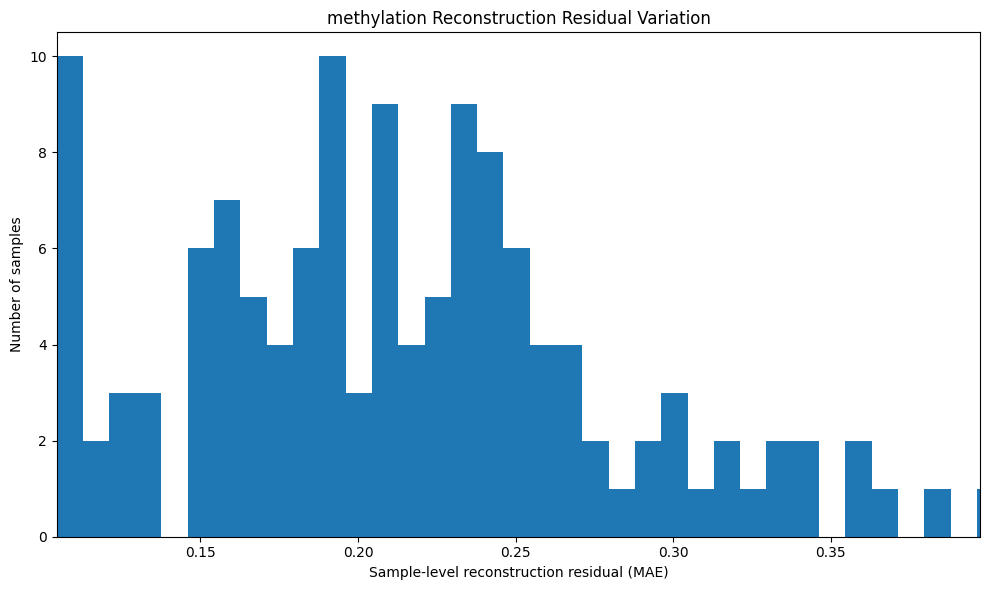

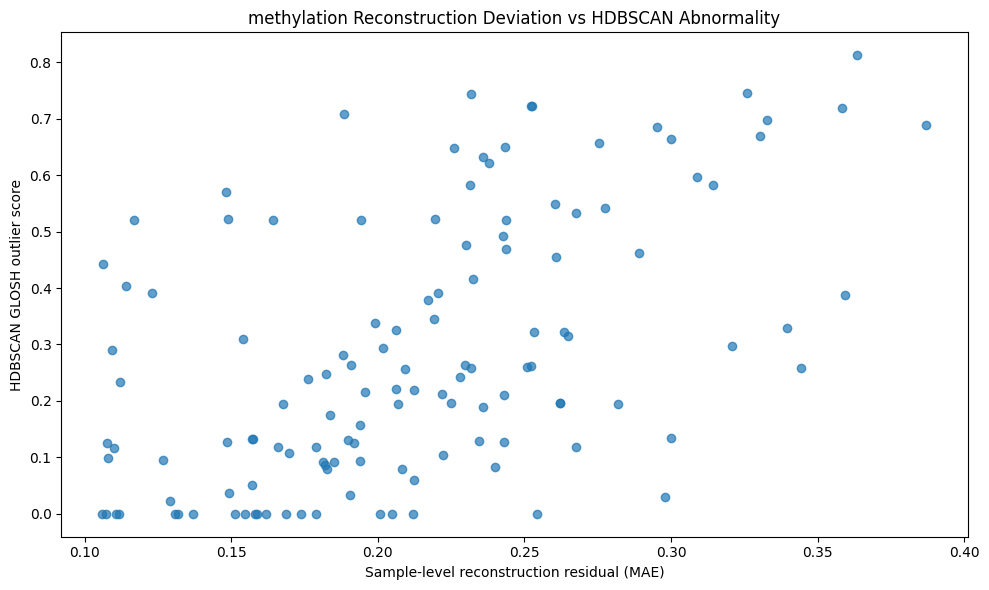

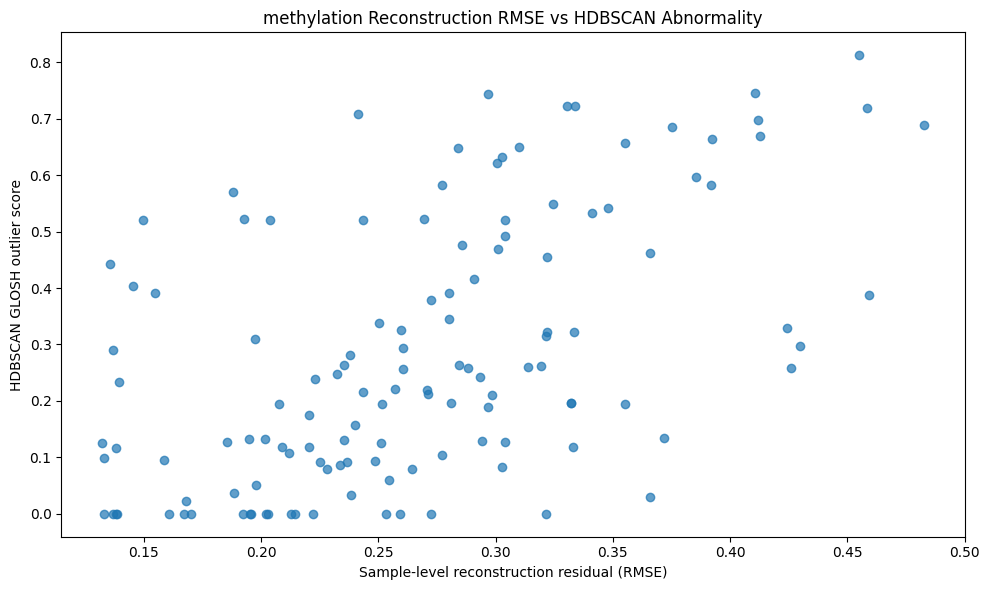


FILES SAVED

Sample-level residuals:
/content/methylation_Reviewer_Corrected_Results/methylation_Sample_Level_Reconstruction_Residuals.csv

Residual summary:
/content/methylation_Reviewer_Corrected_Results/methylation_Residual_Summary.csv

Absolute reconstruction error:
/content/methylation_Reviewer_Corrected_Results/methylation_Absolute_Reconstruction_Error_132x1000.npy

FINAL methylation RESIDUAL ANALYSIS
Number of samples       : 132
Number of features      : 1000
Mean residual MAE       : 0.213606
Median residual MAE     : 0.208779
Mean residual RMSE      : 0.268572
Median residual RMSE    : 0.260369
Spearman rho (MAE)      : 0.574455
Spearman p-value (MAE)  : 5.934052e-13
Spearman rho (RMSE)     : 0.582063
Spearman p-value (RMSE) : 2.481501e-13

Visualization range:
Central 98% MAE  = [0.104447, 0.397343]
Central 98% RMSE = [0.129885, 0.492770]

NOTE:
All 132 observations were retained in the numerical calculations and Spearman correlation tests.
The 1st–99th percentile restricti

In [104]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr


# ============================================================
# 1. INPUT CHECK
# ============================================================

print("\n" + "=" * 80)
print("methylation RESIDUAL VARIATION ANALYSIS")
print("=" * 80)


# ------------------------------------------------------------
# Use the variables that actually exist in the current
# notebook.
# ------------------------------------------------------------

X_original = np.asarray(
    X_test_pca_reconstructed
)

X_reconstructed = np.asarray(
    reconstruction
)

glosh_scores = np.asarray(
    results["OutlierScore"]
)


# ============================================================
# 2. SHAPE VALIDATION
# ============================================================

print("\nInput shapes")
print("-" * 80)

print(
    "Original representation :",
    X_original.shape
)

print(
    "DAE reconstruction      :",
    X_reconstructed.shape
)

print(
    "GLOSH scores            :",
    glosh_scores.shape
)


# ------------------------------------------------------------
# Validate dimensionality
# ------------------------------------------------------------

if X_original.ndim != 2:

    raise ValueError(
        "X_test_pca_reconstructed must be a 2-dimensional matrix."
    )


if X_reconstructed.ndim != 2:

    raise ValueError(
        "reconstruction must be a 2-dimensional matrix."
    )


if X_original.shape != X_reconstructed.shape:

    raise ValueError(
        "Original and reconstructed methylation matrices "
        "must have identical shapes."
    )


if X_original.shape[0] != len(glosh_scores):

    raise ValueError(
        "Number of methylation samples does not match "
        "number of HDBSCAN GLOSH scores."
    )


# ============================================================
# 3. SAMPLE-LEVEL RESIDUAL MAE
# ============================================================

absolute_error = np.abs(
    X_original -
    X_reconstructed
)


sample_residual_mae = np.mean(
    absolute_error,
    axis=1
)


# ============================================================
# 4. SAMPLE-LEVEL RMSE
# ============================================================

sample_residual_rmse = np.sqrt(
    np.mean(
        (
            X_original -
            X_reconstructed
        ) ** 2,
        axis=1
    )
)


# ============================================================
# 5. MAXIMUM FEATURE ERROR
# ============================================================

sample_max_error = np.max(
    absolute_error,
    axis=1
)


# ============================================================
# 6. CENTRAL 98% VISUALIZATION RANGE
#
# 1st percentile → 99th percentile
#
# IMPORTANT:
# These limits are ONLY for plotting.
# No samples are removed from numerical analysis.
# ============================================================

mae_lower = np.percentile(
    sample_residual_mae,
    1
)

mae_upper = np.percentile(
    sample_residual_mae,
    99
)

rmse_lower = np.percentile(
    sample_residual_rmse,
    1
)

rmse_upper = np.percentile(
    sample_residual_rmse,
    99
)


print("\nCentral 98% visualization range")
print("-" * 80)

print(
    f"MAE  : {mae_lower:.6f} "
    f"to {mae_upper:.6f}"
)

print(
    f"RMSE : {rmse_lower:.6f} "
    f"to {rmse_upper:.6f}"
)


# ============================================================
# 7. SUMMARY STATISTICS
#
# ALL 132 samples are retained.
# No extreme observations are removed.
# ============================================================

residual_summary = {

    "N":
        len(sample_residual_mae),

    "Features":
        X_original.shape[1],

    "Mean_MAE":
        np.mean(sample_residual_mae),

    "Median_MAE":
        np.median(sample_residual_mae),

    "SD_MAE":
        np.std(
            sample_residual_mae,
            ddof=1
        ),

    "Min_MAE":
        np.min(sample_residual_mae),

    "Max_MAE":
        np.max(sample_residual_mae),

    "Mean_RMSE":
        np.mean(sample_residual_rmse),

    "Median_RMSE":
        np.median(sample_residual_rmse),

    "SD_RMSE":
        np.std(
            sample_residual_rmse,
            ddof=1
        ),

    "Min_RMSE":
        np.min(sample_residual_rmse),

    "Max_RMSE":
        np.max(sample_residual_rmse),

    "Mean_Max_Feature_Error":
        np.mean(sample_max_error),

    "Max_Feature_Error":
        np.max(sample_max_error)
}


print("\nResidual Summary")
print("-" * 80)

for key, value in residual_summary.items():

    if isinstance(
        value,
        (
            int,
            np.integer
        )
    ):

        print(
            f"{key:<30}: {value}"
        )

    else:

        print(
            f"{key:<30}: {value:.6f}"
        )


# ============================================================
# 8. SAMPLE-LEVEL RESIDUAL TABLE
# ============================================================

residual_df = pd.DataFrame({

    "Sample_Index":
        np.arange(
            len(sample_residual_mae)
        ),

    "Residual_MAE":
        sample_residual_mae,

    "Residual_RMSE":
        sample_residual_rmse,

    "Max_Feature_Error":
        sample_max_error,

    "GLOSH_Outlier_Score":
        glosh_scores
})


# ============================================================
# 9. ADD EXISTING HDBSCAN INFORMATION
#
# This allows the residual table to be directly connected
# to the existing results dictionary.
# ============================================================

if "Cluster" in results:

    residual_df["Cluster"] = np.asarray(
        results["Cluster"]
    )


if "Probability" in results:

    residual_df["HDBSCAN_Probability"] = np.asarray(
        results["Probability"]
    )


if "Noise_Confidence" in results:

    residual_df["Noise_Confidence"] = np.asarray(
        results["Noise_Confidence"]
    )


if "Noise_Status" in results:

    residual_df["Noise_Status"] = np.asarray(
        results["Noise_Status"]
    )


if "Outlier_Category" in results:

    residual_df["Outlier_Category"] = np.asarray(
        results["Outlier_Category"]
    )


# ============================================================
# 10. SPEARMAN — MAE vs GLOSH
# ============================================================

rho_mae, p_mae = spearmanr(
    sample_residual_mae,
    glosh_scores
)


# ============================================================
# 11. SPEARMAN — RMSE vs GLOSH
# ============================================================

rho_rmse, p_rmse = spearmanr(
    sample_residual_rmse,
    glosh_scores
)


print("\nSpearman Rank Correlation")
print("-" * 80)

print(
    "Residual MAE vs GLOSH"
)

print(
    f"Spearman rho : {rho_mae:.6f}"
)

print(
    f"p-value      : {p_mae:.6e}"
)

print()

print(
    "Residual RMSE vs GLOSH"
)

print(
    f"Spearman rho : {rho_rmse:.6f}"
)

print(
    f"p-value      : {p_rmse:.6e}"
)


# ============================================================
# 12. ADD CORRELATION RESULTS TO SUMMARY
# ============================================================

residual_summary[
    "Spearman_Rho_MAE_GLOSH"
] = rho_mae

residual_summary[
    "Spearman_P_MAE_GLOSH"
] = p_mae

residual_summary[
    "Spearman_Rho_RMSE_GLOSH"
] = rho_rmse

residual_summary[
    "Spearman_P_RMSE_GLOSH"
] = p_rmse


# ============================================================
# 13. RESIDUAL HISTOGRAM
#
# Only the central 98% is displayed.
# ALL observations remain in the underlying data.
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    sample_residual_mae,
    bins=40
)

plt.xlim(
    mae_lower,
    mae_upper
)

plt.xlabel(
    "Sample-level reconstruction residual (MAE)"
)

plt.ylabel(
    "Number of samples"
)

plt.title(
    "methylation Reconstruction Residual Variation"
)

plt.tight_layout()

plt.show()


# ============================================================
# 14. RESIDUAL vs GLOSH
#
# Visualization uses central 98% MAE range.
#
# IMPORTANT:
# Spearman correlation above uses ALL 132 samples.
# ============================================================

visual_mask = (
    sample_residual_mae >= mae_lower
) & (
    sample_residual_mae <= mae_upper
)


plt.figure(
    figsize=(10, 6)
)

plt.scatter(
    sample_residual_mae[
        visual_mask
    ],
    glosh_scores[
        visual_mask
    ],
    alpha=0.7
)

plt.xlabel(
    "Sample-level reconstruction residual (MAE)"
)

plt.ylabel(
    "HDBSCAN GLOSH outlier score"
)

plt.title(
    "methylation Reconstruction Deviation vs HDBSCAN Abnormality"
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. RMSE vs GLOSH
# ============================================================

visual_mask_rmse = (
    sample_residual_rmse >= rmse_lower
) & (
    sample_residual_rmse <= rmse_upper
)


plt.figure(
    figsize=(10, 6)
)

plt.scatter(
    sample_residual_rmse[
        visual_mask_rmse
    ],
    glosh_scores[
        visual_mask_rmse
    ],
    alpha=0.7
)

plt.xlabel(
    "Sample-level reconstruction residual (RMSE)"
)

plt.ylabel(
    "HDBSCAN GLOSH outlier score"
)

plt.title(
    "methylation Reconstruction RMSE vs HDBSCAN Abnormality"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. OUTPUT DIRECTORY
# ============================================================

if "OUTPUT_DIR" in globals():

    residual_output_dir = OUTPUT_DIR

elif "RESULTS_DIR" in globals():

    residual_output_dir = RESULTS_DIR

else:

    residual_output_dir = "methylation_Residual_Analysis"


os.makedirs(
    residual_output_dir,
    exist_ok=True
)


# ============================================================
# 17. SAVE SAMPLE-LEVEL RESIDUALS
# ============================================================

residual_file = os.path.join(
    residual_output_dir,
    "methylation_Sample_Level_Reconstruction_Residuals.csv"
)


residual_df.to_csv(
    residual_file,
    index=False
)


# ============================================================
# 18. SAVE SUMMARY
# ============================================================

summary_df = pd.DataFrame([
    residual_summary
])


summary_file = os.path.join(
    residual_output_dir,
    "methylation_Residual_Summary.csv"
)


summary_df.to_csv(
    summary_file,
    index=False
)


# ============================================================
# 19. SAVE RESIDUAL MATRICES
#
# Useful for later gene-level analysis.
# ============================================================

absolute_error_file = os.path.join(
    residual_output_dir,
    "methylation_Absolute_Reconstruction_Error_132x1000.npy"
)


np.save(
    absolute_error_file,
    absolute_error
)


# ============================================================
# 20. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print(
    "\nSample-level residuals:"
)

print(
    residual_file
)

print(
    "\nResidual summary:"
)

print(
    summary_file
)

print(
    "\nAbsolute reconstruction error:"
)

print(
    absolute_error_file
)


# ============================================================
# 21. FINAL INTERPRETATION
# ============================================================

print("\n" + "=" * 80)
print("FINAL methylation RESIDUAL ANALYSIS")
print("=" * 80)

print(
    f"Number of samples       : "
    f"{len(sample_residual_mae)}"
)

print(
    f"Number of features      : "
    f"{X_original.shape[1]}"
)

print(
    f"Mean residual MAE       : "
    f"{np.mean(sample_residual_mae):.6f}"
)

print(
    f"Median residual MAE     : "
    f"{np.median(sample_residual_mae):.6f}"
)

print(
    f"Mean residual RMSE      : "
    f"{np.mean(sample_residual_rmse):.6f}"
)

print(
    f"Median residual RMSE    : "
    f"{np.median(sample_residual_rmse):.6f}"
)

print(
    f"Spearman rho (MAE)      : "
    f"{rho_mae:.6f}"
)

print(
    f"Spearman p-value (MAE)  : "
    f"{p_mae:.6e}"
)

print(
    f"Spearman rho (RMSE)     : "
    f"{rho_rmse:.6f}"
)

print(
    f"Spearman p-value (RMSE) : "
    f"{p_rmse:.6e}"
)

print(
    "\nVisualization range:"
)

print(
    f"Central 98% MAE  = "
    f"[{mae_lower:.6f}, {mae_upper:.6f}]"
)

print(
    f"Central 98% RMSE = "
    f"[{rmse_lower:.6f}, {rmse_upper:.6f}]"
)

print(
    "\nNOTE:"
)

print(
    "All 132 observations were retained in the numerical "
    "calculations and Spearman correlation tests."
)

print(
    "The 1st–99th percentile restriction was used only "
    "for visualization."
)

print(
    "\nAnalysis completed successfully."
)



M4 IEEE DETAILED RESULTS
 Noise_Level  Actual_Noise_STD  Mean_MAE  Median_MAE   SD_MAE  Mean_RMSE  Median_RMSE  SD_RMSE  Max_MAE  Max_RMSE
        0.10          0.100346  0.420496    0.415140 0.163448   0.555918     0.549033 0.220210 1.022906  1.338240
        0.25          0.250865  0.467771    0.456432 0.149519   0.609215     0.595510 0.202658 1.047071  1.362691
        0.50          0.501729  0.594221    0.578967 0.125001   0.759083     0.737699 0.168380 1.119797  1.441684
        1.00          1.003458  0.923672    0.904723 0.092507   1.164253     1.139065 0.120394 1.351321  1.714703


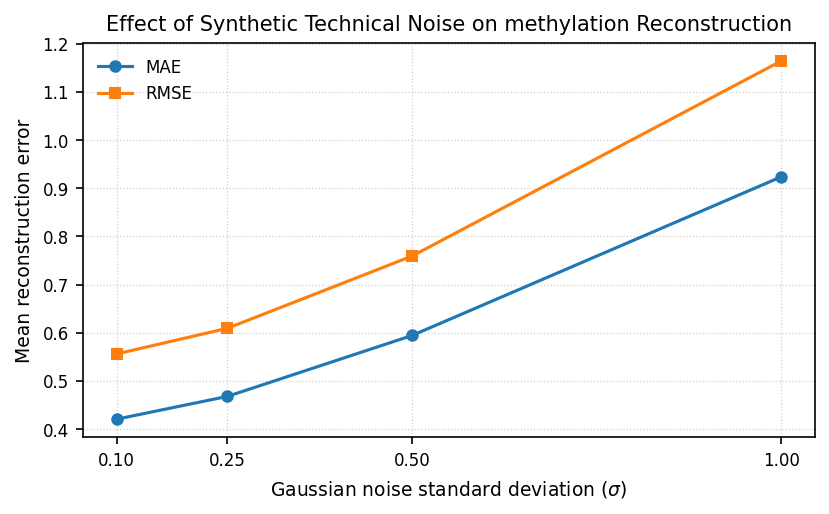

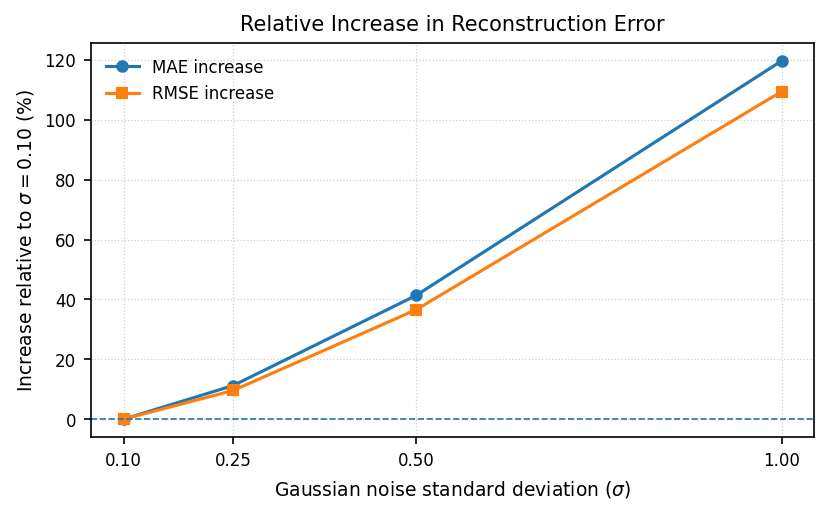

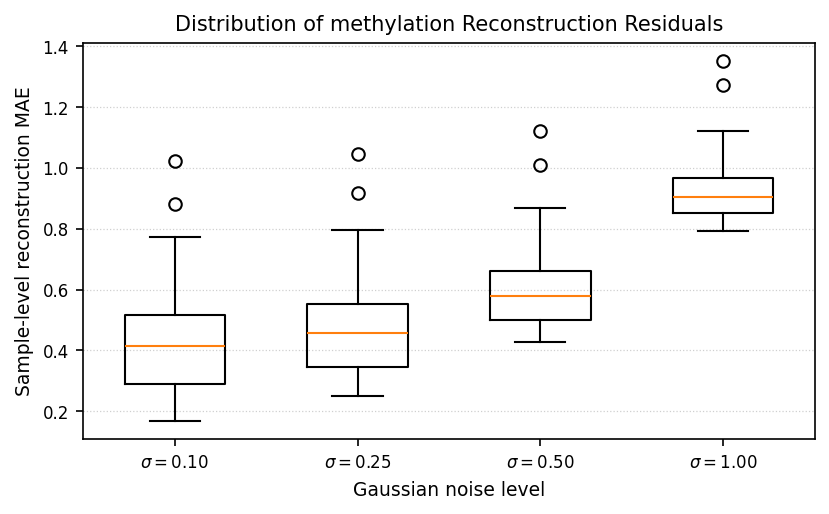

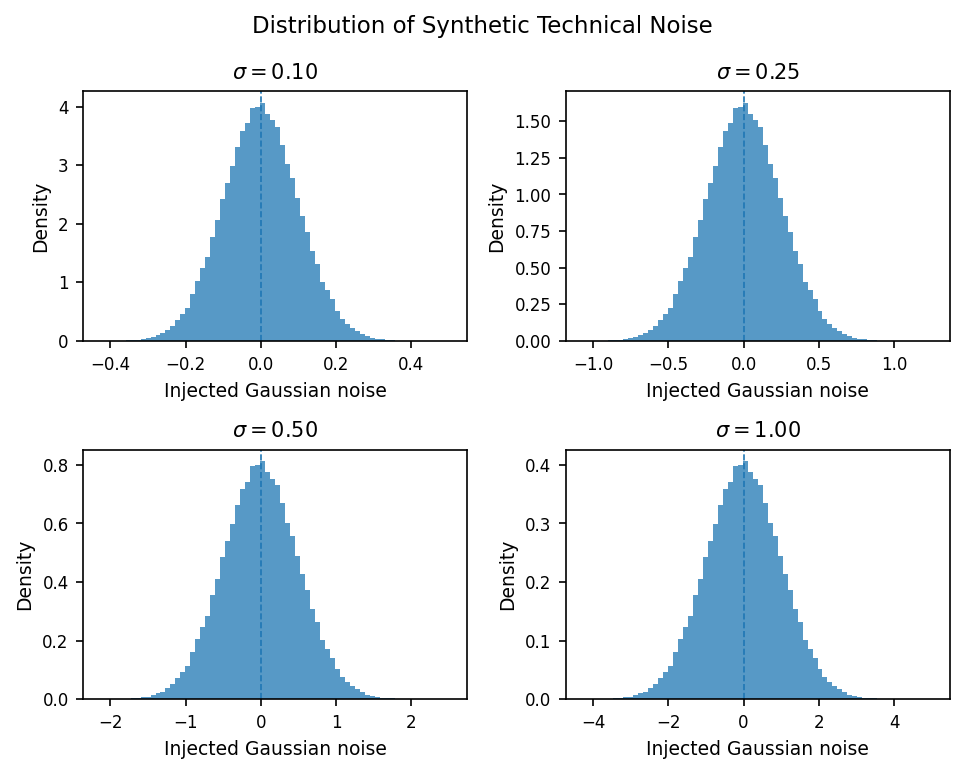

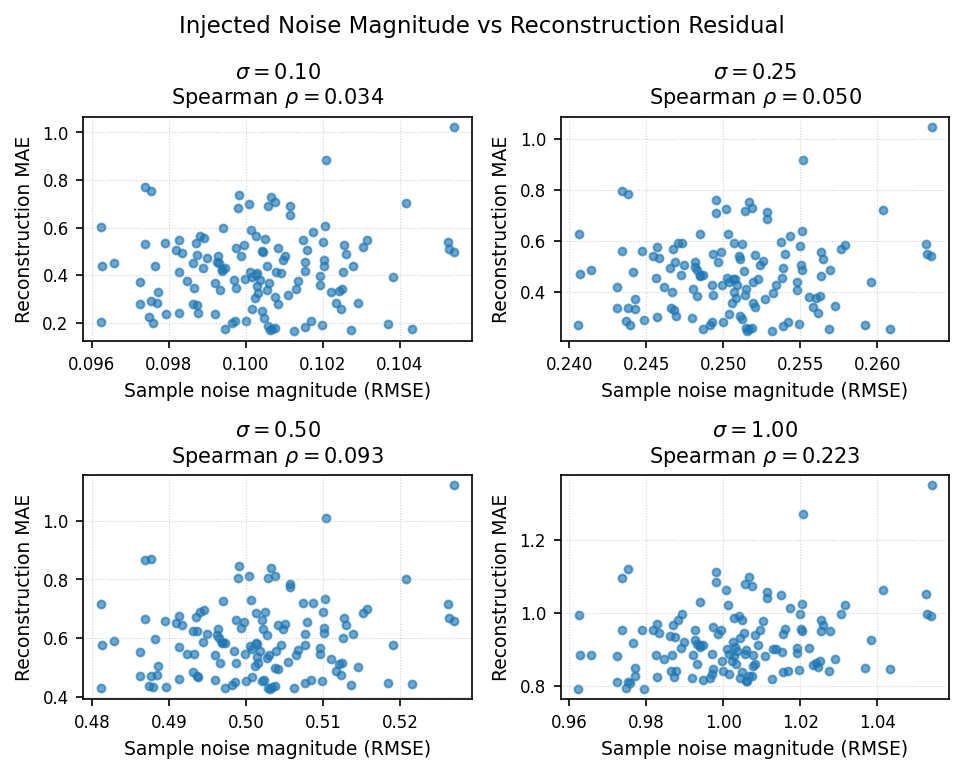

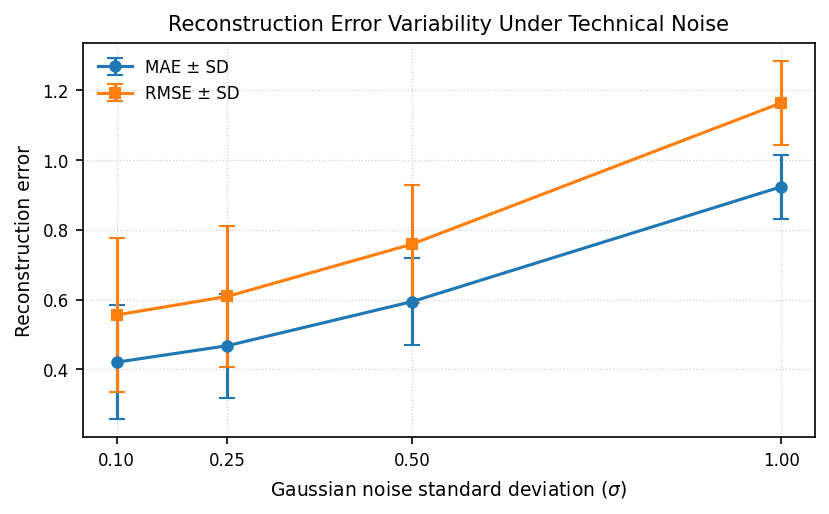

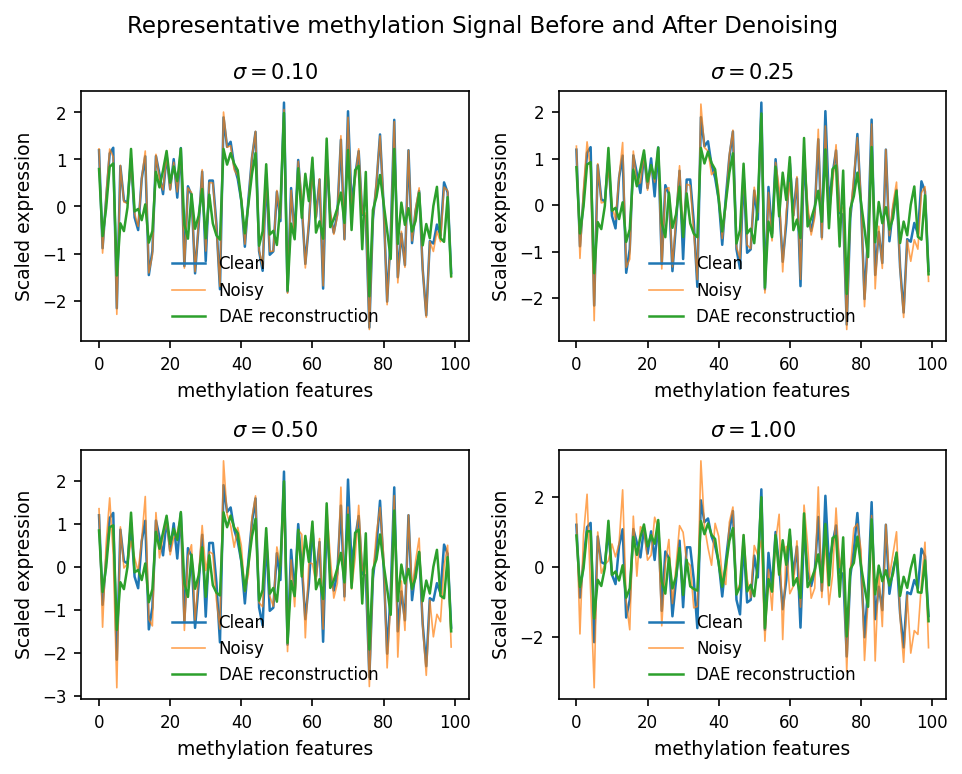

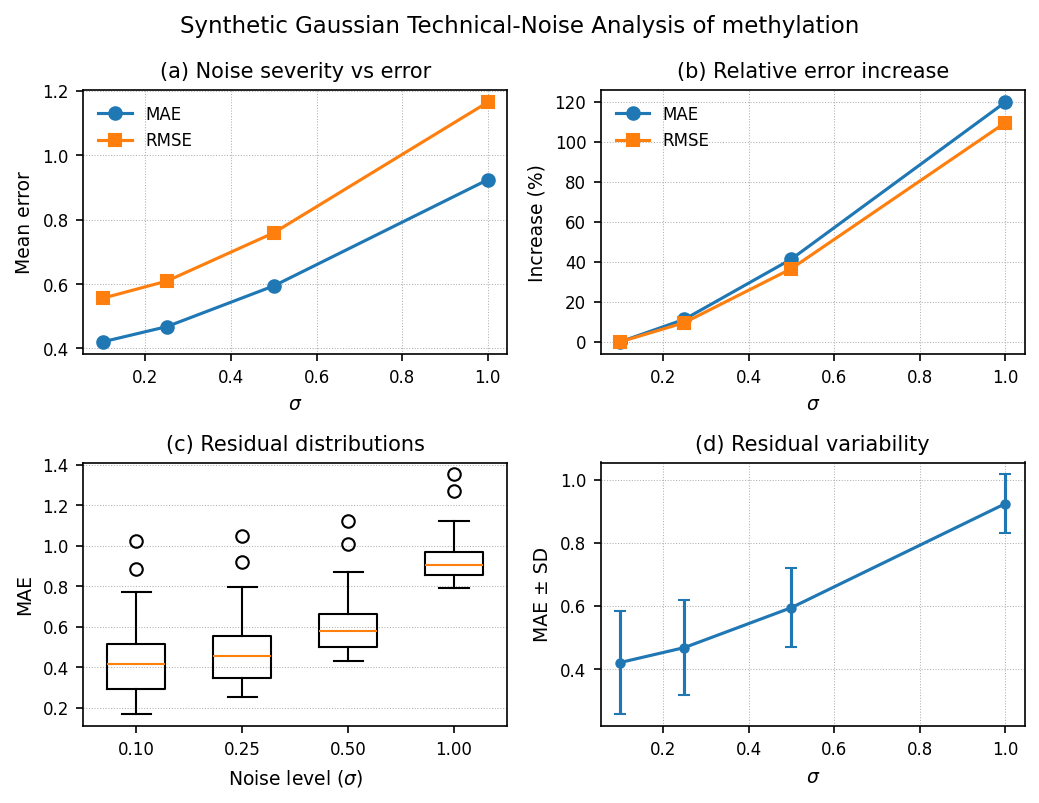



M4 — FINAL SYNTHETIC TECHNICAL-NOISE ANALYSIS

Noise σ = 0.10
  Actual noise STD : 0.100346
  Mean MAE         : 0.420496
  Median MAE       : 0.415140
  Mean RMSE        : 0.555918
  Median RMSE      : 0.549033

Noise σ = 0.25
  Actual noise STD : 0.250865
  Mean MAE         : 0.467771
  Median MAE       : 0.456432
  Mean RMSE        : 0.609215
  Median RMSE      : 0.595510

Noise σ = 0.50
  Actual noise STD : 0.501729
  Mean MAE         : 0.594221
  Median MAE       : 0.578967
  Mean RMSE        : 0.759083
  Median RMSE      : 0.737699

Noise σ = 1.00
  Actual noise STD : 1.003458
  Mean MAE         : 0.923672
  Median MAE       : 0.904723
  Mean RMSE        : 1.164253
  Median RMSE      : 1.139065


IEEE VISUALIZATIONS SAVED
/content/methylation_Reviewer_Corrected_Results/M4_IEEE_Visualizations

Generated figures:
   Fig_M4_01_Noise_vs_Error.pdf
   Fig_M4_02_Relative_Error_Increase.pdf
   Fig_M4_03_Residual_Boxplot.pdf
   Fig_M4_04_Gaussian_Noise_Distributions.pdf
   Fig_M4_05_Noi

In [106]:
# ============================================================
# M4 — IEEE-QUALITY SYNTHETIC TECHNICAL NOISE VISUALIZATION
# mRNA
#
# IMPORTANT:
# This visualization uses the EXACT Gaussian noise procedure
# from the original M4 experiment.
#
# Clean scaled data:
#       X_test_scaled
#
# Noise:
#       N(0, sigma^2)
#
# Noisy data:
#       X_noisy = X_test_scaled + noise
#
# DAE:
#       dae_mse.predict(X_noisy)
#
# Residual:
#       mean(|X_noisy - reconstruction|)
# ============================================================


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr


# ============================================================
# 1. SETTINGS
# ============================================================

IEEE_OUTPUT_DIR = os.path.join(
    OUTPUT_DIR,
    "M4_IEEE_Visualizations"
)

os.makedirs(
    IEEE_OUTPUT_DIR,
    exist_ok=True
)

NOISE_LEVELS = [
    0.10,
    0.25,
    0.50,
    1.00
]

SEED = 42


# ============================================================
# 2. RE-RUN EXACT M4 EXPERIMENT
# ============================================================

m4_detailed_results = []

m4_noise = {}
m4_noisy_data = {}
m4_reconstruction = {}
m4_mae = {}
m4_rmse = {}


for level in NOISE_LEVELS:

    # --------------------------------------------------------
    # EXACT ORIGINAL NOISE INJECTION
    # --------------------------------------------------------

    rng = np.random.default_rng(SEED)

    noise = rng.normal(
        loc=0.0,
        scale=level,
        size=X_test_scaled.shape
    )

    X_noisy = X_test_scaled + noise


    # --------------------------------------------------------
    # DAE RECONSTRUCTION
    # --------------------------------------------------------

    reconstruction = dae_mse.predict(
        X_noisy,
        verbose=0
    )


    # --------------------------------------------------------
    # SAMPLE-LEVEL MAE
    # --------------------------------------------------------

    mae = np.mean(
        np.abs(
            X_noisy -
            reconstruction
        ),
        axis=1
    )


    # --------------------------------------------------------
    # SAMPLE-LEVEL RMSE
    # --------------------------------------------------------

    rmse = np.sqrt(
        np.mean(
            (
                X_noisy -
                reconstruction
            ) ** 2,
            axis=1
        )
    )


    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    m4_noise[level] = noise

    m4_noisy_data[level] = X_noisy

    m4_reconstruction[level] = reconstruction

    m4_mae[level] = mae

    m4_rmse[level] = rmse


    # --------------------------------------------------------
    # SUMMARY
    # --------------------------------------------------------

    m4_detailed_results.append({

        "Noise_Level": level,

        "Actual_Noise_STD":
            np.std(noise),

        "Mean_MAE":
            np.mean(mae),

        "Median_MAE":
            np.median(mae),

        "SD_MAE":
            np.std(mae, ddof=1),

        "Mean_RMSE":
            np.mean(rmse),

        "Median_RMSE":
            np.median(rmse),

        "SD_RMSE":
            np.std(rmse, ddof=1),

        "Max_MAE":
            np.max(mae),

        "Max_RMSE":
            np.max(rmse)

    })


m4_df = pd.DataFrame(
    m4_detailed_results
)


# ============================================================
# 3. SAVE DETAILED RESULTS
# ============================================================

m4_df.to_csv(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "M4_IEEE_Detailed_Results.csv"
    ),
    index=False
)


print("\n")
print("=" * 80)
print("M4 IEEE DETAILED RESULTS")
print("=" * 80)

print(
    m4_df.to_string(
        index=False
    )
)


# ============================================================
# 4. IEEE STYLE
# ============================================================

plt.rcParams.update({

    "font.family": "serif",

    "font.serif":
        ["Times New Roman", "Times"],

    "font.size":
        9,

    "axes.labelsize":
        9,

    "axes.titlesize":
        10,

    "xtick.labelsize":
        8,

    "ytick.labelsize":
        8,

    "legend.fontsize":
        8,

    "axes.linewidth":
        0.8,

    "xtick.major.width":
        0.8,

    "ytick.major.width":
        0.8,

    "figure.dpi":
        150,

    "savefig.dpi":
        600,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42
})


# ============================================================
# FIGURE 1
# NOISE LEVEL vs MAE / RMSE
# ============================================================

fig, ax = plt.subplots(
    figsize=(5.6, 3.5)
)

ax.plot(
    m4_df["Noise_Level"],
    m4_df["Mean_MAE"],
    marker="o",
    markersize=5,
    linewidth=1.5,
    label="MAE"
)

ax.plot(
    m4_df["Noise_Level"],
    m4_df["Mean_RMSE"],
    marker="s",
    markersize=5,
    linewidth=1.5,
    label="RMSE"
)

ax.set_xlabel(
    "Gaussian noise standard deviation ($\\sigma$)"
)

ax.set_ylabel(
    "Mean reconstruction error"
)

ax.set_title(
    "Effect of Synthetic Technical Noise on methylation Reconstruction"
)

ax.set_xticks(
    NOISE_LEVELS
)

ax.legend(
    frameon=False
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.6,
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_01_Noise_vs_Error.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_01_Noise_vs_Error.png"
    ),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 2
# ERROR INCREASE RELATIVE TO LOWEST NOISE
# ============================================================

baseline_mae = m4_df["Mean_MAE"].iloc[0]

baseline_rmse = m4_df["Mean_RMSE"].iloc[0]

mae_increase = (
    (
        m4_df["Mean_MAE"]
        -
        baseline_mae
    )
    /
    baseline_mae
) * 100

rmse_increase = (
    (
        m4_df["Mean_RMSE"]
        -
        baseline_rmse
    )
    /
    baseline_rmse
) * 100


fig, ax = plt.subplots(
    figsize=(5.6, 3.5)
)

ax.plot(
    m4_df["Noise_Level"],
    mae_increase,
    marker="o",
    linewidth=1.5,
    markersize=5,
    label="MAE increase"
)

ax.plot(
    m4_df["Noise_Level"],
    rmse_increase,
    marker="s",
    linewidth=1.5,
    markersize=5,
    label="RMSE increase"
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

ax.set_xlabel(
    "Gaussian noise standard deviation ($\\sigma$)"
)

ax.set_ylabel(
    "Increase relative to $\\sigma=0.10$ (%)"
)

ax.set_title(
    "Relative Increase in Reconstruction Error"
)

ax.set_xticks(
    NOISE_LEVELS
)

ax.legend(
    frameon=False
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.6,
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_02_Relative_Error_Increase.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_02_Relative_Error_Increase.png"
    ),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 3
# SAMPLE-LEVEL RESIDUAL DISTRIBUTIONS
# ============================================================

fig, ax = plt.subplots(
    figsize=(5.6, 3.5)
)

positions = np.arange(
    1,
    len(NOISE_LEVELS) + 1
)

box_data = [
    m4_mae[level]
    for level in NOISE_LEVELS
]

bp = ax.boxplot(
    box_data,
    positions=positions,
    widths=0.55,
    showfliers=True
)

ax.set_xticks(
    positions
)

ax.set_xticklabels(
    [
        f"$\\sigma={x:.2f}$"
        for x in NOISE_LEVELS
    ]
)

ax.set_xlabel(
    "Gaussian noise level"
)

ax.set_ylabel(
    "Sample-level reconstruction MAE"
)

ax.set_title(
    "Distribution of methylation Reconstruction Residuals"
)

ax.grid(
    axis="y",
    linestyle=":",
    linewidth=0.6,
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_03_Residual_Boxplot.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_03_Residual_Boxplot.png"
    ),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 4
# GAUSSIAN NOISE DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(6.5, 5.2)
)

axes = axes.flatten()


for ax, level in zip(
    axes,
    NOISE_LEVELS
):

    noise = m4_noise[level].flatten()

    # Limit plotting points only
    # numerical calculations remain complete

    if len(noise) > 100000:

        rng = np.random.default_rng(
            SEED
        )

        idx = rng.choice(
            len(noise),
            100000,
            replace=False
        )

        noise_plot = noise[idx]

    else:

        noise_plot = noise


    ax.hist(
        noise_plot,
        bins=70,
        density=True,
        alpha=0.75
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=0.8
    )

    ax.set_title(
        f"$\\sigma={level:.2f}$"
    )

    ax.set_xlabel(
        "Injected Gaussian noise"
    )

    ax.set_ylabel(
        "Density"
    )


fig.suptitle(
    "Distribution of Synthetic Technical Noise",
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_04_Gaussian_Noise_Distributions.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_04_Gaussian_Noise_Distributions.png"
    ),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 5
# NOISE MAGNITUDE vs RECONSTRUCTION ERROR
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(6.5, 5.2)
)

axes = axes.flatten()


for ax, level in zip(
    axes,
    NOISE_LEVELS
):

    noise = m4_noise[level]

    mae = m4_mae[level]


    sample_noise_rmse = np.sqrt(
        np.mean(
            noise ** 2,
            axis=1
        )
    )


    rho, p = spearmanr(
        sample_noise_rmse,
        mae
    )


    ax.scatter(
        sample_noise_rmse,
        mae,
        s=14,
        alpha=0.65
    )


    ax.set_title(
        f"$\\sigma={level:.2f}$"
        f"\nSpearman $\\rho={rho:.3f}$"
    )

    ax.set_xlabel(
        "Sample noise magnitude (RMSE)"
    )

    ax.set_ylabel(
        "Reconstruction MAE"
    )

    ax.grid(
        True,
        linestyle=":",
        linewidth=0.5,
        alpha=0.6
    )


fig.suptitle(
    "Injected Noise Magnitude vs Reconstruction Residual",
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_05_Noise_vs_Residual.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_05_Noise_vs_Residual.png"
    ),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 6
# MEAN ± SD
# ============================================================

fig, ax = plt.subplots(
    figsize=(5.6, 3.5)
)

ax.errorbar(
    m4_df["Noise_Level"],
    m4_df["Mean_MAE"],
    yerr=m4_df["SD_MAE"],
    marker="o",
    markersize=5,
    linewidth=1.5,
    capsize=4,
    label="MAE ± SD"
)

ax.errorbar(
    m4_df["Noise_Level"],
    m4_df["Mean_RMSE"],
    yerr=m4_df["SD_RMSE"],
    marker="s",
    markersize=5,
    linewidth=1.5,
    capsize=4,
    label="RMSE ± SD"
)

ax.set_xlabel(
    "Gaussian noise standard deviation ($\\sigma$)"
)

ax.set_ylabel(
    "Reconstruction error"
)

ax.set_title(
    "Reconstruction Error Variability Under Technical Noise"
)

ax.set_xticks(
    NOISE_LEVELS
)

ax.legend(
    frameon=False
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.6,
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_06_Error_Variability.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_06_Error_Variability.png"
    ),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 7
# CLEAN vs NOISY vs DAE RECONSTRUCTION
# REPRESENTATIVE SAMPLE
# ============================================================

sample_index = 0

fig, axes = plt.subplots(
    2,
    2,
    figsize=(6.5, 5.2)
)

axes = axes.flatten()


for ax, level in zip(
    axes,
    NOISE_LEVELS
):

    clean = X_test_scaled[
        sample_index
    ]

    noisy = m4_noisy_data[
        level
    ][sample_index]

    reconstructed = m4_reconstruction[
        level
    ][sample_index]


    n_features = len(clean)

    # Show first 100 features
    plot_features = min(
        100,
        n_features
    )

    x_axis = np.arange(
        plot_features
    )


    ax.plot(
        x_axis,
        clean[:plot_features],
        linewidth=1.2,
        label="Clean"
    )

    ax.plot(
        x_axis,
        noisy[:plot_features],
        linewidth=0.8,
        alpha=0.7,
        label="Noisy"
    )

    ax.plot(
        x_axis,
        reconstructed[:plot_features],
        linewidth=1.2,
        label="DAE reconstruction"
    )


    ax.set_title(
        f"$\\sigma={level:.2f}$"
    )

    ax.set_xlabel(
        "methylation features"
    )

    ax.set_ylabel(
        "Scaled expression"
    )

    ax.legend(
        frameon=False
    )


fig.suptitle(
    "Representative methylation Signal Before and After Denoising",
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_07_Clean_Noisy_Reconstruction.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_07_Clean_Noisy_Reconstruction.png"
    ),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 8
# IEEE FINAL SUMMARY
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(7.0, 5.4)
)


# ------------------------------------------------------------
# (a) Noise vs error
# ------------------------------------------------------------

ax = axes[0, 0]

ax.plot(
    m4_df["Noise_Level"],
    m4_df["Mean_MAE"],
    marker="o",
    linewidth=1.5,
    label="MAE"
)

ax.plot(
    m4_df["Noise_Level"],
    m4_df["Mean_RMSE"],
    marker="s",
    linewidth=1.5,
    label="RMSE"
)

ax.set_xlabel(
    "$\\sigma$"
)

ax.set_ylabel(
    "Mean error"
)

ax.set_title(
    "(a) Noise severity vs error"
)

ax.legend(
    frameon=False
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.5
)


# ------------------------------------------------------------
# (b) Error increase
# ------------------------------------------------------------

ax = axes[0, 1]

ax.plot(
    m4_df["Noise_Level"],
    mae_increase,
    marker="o",
    linewidth=1.5,
    label="MAE"
)

ax.plot(
    m4_df["Noise_Level"],
    rmse_increase,
    marker="s",
    linewidth=1.5,
    label="RMSE"
)

ax.set_xlabel(
    "$\\sigma$"
)

ax.set_ylabel(
    "Increase (%)"
)

ax.set_title(
    "(b) Relative error increase"
)

ax.legend(
    frameon=False
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.5
)


# ------------------------------------------------------------
# (c) Residual boxplot
# ------------------------------------------------------------

ax = axes[1, 0]

ax.boxplot(
    [
        m4_mae[level]
        for level in NOISE_LEVELS
    ],
    labels=[
        f"{level:.2f}"
        for level in NOISE_LEVELS
    ],
    widths=0.55
)

ax.set_xlabel(
    "Noise level ($\\sigma$)"
)

ax.set_ylabel(
    "MAE"
)

ax.set_title(
    "(c) Residual distributions"
)

ax.grid(
    axis="y",
    linestyle=":",
    linewidth=0.5
)


# ------------------------------------------------------------
# (d) Mean ± SD
# ------------------------------------------------------------

ax = axes[1, 1]

ax.errorbar(
    m4_df["Noise_Level"],
    m4_df["Mean_MAE"],
    yerr=m4_df["SD_MAE"],
    marker="o",
    linewidth=1.5,
    markersize=4,
    capsize=3
)

ax.set_xlabel(
    "$\\sigma$"
)

ax.set_ylabel(
    "MAE ± SD"
)

ax.set_title(
    "(d) Residual variability"
)

ax.grid(
    True,
    linestyle=":",
    linewidth=0.5
)


fig.suptitle(
    "Synthetic Gaussian Technical-Noise Analysis of methylation",
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_08_IEEE_Final_Summary.pdf"
    ),
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        IEEE_OUTPUT_DIR,
        "Fig_M4_08_IEEE_Final_Summary.png"
    ),
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. FINAL NUMERICAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("M4 — FINAL SYNTHETIC TECHNICAL-NOISE ANALYSIS")
print("=" * 80)

for _, row in m4_df.iterrows():

    print(
        f"\nNoise σ = {row['Noise_Level']:.2f}"
    )

    print(
        f"  Actual noise STD : "
        f"{row['Actual_Noise_STD']:.6f}"
    )

    print(
        f"  Mean MAE         : "
        f"{row['Mean_MAE']:.6f}"
    )

    print(
        f"  Median MAE       : "
        f"{row['Median_MAE']:.6f}"
    )

    print(
        f"  Mean RMSE        : "
        f"{row['Mean_RMSE']:.6f}"
    )

    print(
        f"  Median RMSE      : "
        f"{row['Median_RMSE']:.6f}"
    )


# ============================================================
# 6. FINAL OUTPUT LOCATION
# ============================================================

print("\n")
print("=" * 80)
print("IEEE VISUALIZATIONS SAVED")
print("=" * 80)

print(
    IEEE_OUTPUT_DIR
)

print("\nGenerated figures:")

for filename in sorted(
    os.listdir(
        IEEE_OUTPUT_DIR
    )
):

    if filename.endswith(".pdf"):

        print(
            "  ",
            filename
        )

print("\nAnalysis completed successfully.")